In [13]:
import os, pickle, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt
import shap
import time

# from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc

In [55]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [57]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [2]:
## Definitions

## Defines

# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

def print_progress(iteration, total, prefix='', suffix='', decimals=1, length=50, fill='█', printEnd="\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

In [3]:
## Configs
SEED = 64

# base = '/media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN'
base = '/media/bami/JHA/24-07_nedis/KNN'
out = f'{base}/Clustering/P1_NEC/Surv'
# ipt = f'{base}/Dataset'
# ipt = f'{base}/Clustering/P1_NEC/P1_C4'
ipt = f'{base}/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA/PCA30/C8_Sil-Opt'

base1 = '/media/bami/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp'
colmap = f'{base}/Clustering/M13'

# out = f'{base}/Clustering/M01_Main'
# out = f'{base}/Clustering/M13/1_Whole'
# Z_dir = f'{base}/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA'

In [20]:
# Data import
# df = pd.read_csv(f"{ipt}/knn_prep-fin_M08.csv")
# df = pd.read_csv(f"{ipt}/knn_prep-fin_M08-alive.csv")
df = pd.read_csv(f'{ipt}/KNN_df_combined_1.csv')
df.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
df.set_index('idx_code', inplace=True)
print(len(df.columns))
df

163


Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,1,0,0,0,1,0,0,0,4
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,1,0,0,0,1,0,0,0,6
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,1,0,0,0,1,0,0,0,2
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,1,0,0,0,1,0,0,0,8
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,1,0,0,0,1,0,0,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,1,0,0,0,1,0,0,0,4
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,1,0,0,0,1,0,0,0,6
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,1,0,0,0,1,0,0,0,4


In [15]:
# # Drop cols
# datetime_cols = [
#     'ntetdt','ntetdty','date362','date36','menidt','pdaddth','pdaddt',
#     'birthdt','admd','birtm','bird','efydt','death_dt','iperrdt'
# ]
# rsndth_cols  = ['death_CR','death_NL','death_Inf','death_GI','death_CA','death_Otr']
# drop_cols = ['ga'] + datetime_cols + rsndth_cols

# target_keys = [
#     'ntet_','ntety_','ntetoy_','SEPS_bef_NTET','SEPS_aft_NTET',
#     'NTET_day','PDA_7d_NTET','invfpod','iperr_','iperroy_',
#     'SEPS_bef_IPERR','SEPS_aft_IPERR','IPERR_day','PDA_7d_IPERR',
#     'PDA_7d_IPERRorNTET','SEPS_bef_IPERRorNTET','SEPS_aft_IPERRorNTET',
#     '7d_PDA','bdp','bdp_Moderate+','strdu_','inhg_','pvl_','nese_',
#     'seps_3','pmirnsg_','pmirnsgnd','stday','oxyt36_','arre36_',
#     'bwei','btem','bhei','bhead'
# ]
# tgt_cols = [c for c in df.columns
#             if c in target_keys or any(c.startswith(p) for p in target_keys)]

feature_cols = [
    'iarvppd', 'bdp_Moderate+', 'stday', 'arre36_0', 'arre28_6', 'oxyt36_1', 'arre28_0'
    , 'strdu_1', 'strdu_0', 'pmirnsg_1+', 'ga', 'bwei', 'oxyt28_3', 'bdp', 'EFYN_day'
    , 'bhead', 'bhei', 'oxyt28_1', 'sft_0', 'sft_1', 'oxyt36_3', 'arre36_6', 'niarvrpd'
    , 'inhg_1', 'inhg_0', 'pmirnsg_0', 'arre36_7', 'eythtran_1', 'eythtran_0', 'oxyt36_2'
    , 'sftun', 'apgs1', 'inhg_2+', 'aoxyuppd', 'PDA_TRD', 'lbp_1', 'lbp_0', 'apgs5'
    , 'oxyt28_4', 'resu_0', 'pda_non-treatment', 'seps_1', 'seps_2', 'ph_1', 'inhg_3+'
    , 'pmirnsgnd', 'resu_1', 'nese_0', 'nese_1', 'niarvhfnc', 'pvl_2', 'htn_2', 'meni_0'
    , 'meni_1', 'pvl_1', 'htn_1', 'bbphuk', 'bbbeuk', 'als_1', 'als_0', 'bheaduk', 'prom_0'
    , 'chor_1', 'bheiuk', 'btem', 'chor_0', 'mph_1', 'mph_0', 'prom_1', 'amni_1', 'atbyn_1'
    , 'PPHN', 'efyn', 'bbbe', 'prep_1', 'prep_2', '7d_PDA', 'amni_4', 'arre28_7'
    , 'atbyn_Unknown', 'bbph', 'pda_unknown', 'bpia_1', 'pvl_3', 'bpia_2', 'prom_Unknown'
    , 'oxyt28_2', 'btemuk', 'amni_2', 'bpia_3', 'ster_Unknown', 'ster_1', 'mulg_multiple'
    , 'mulg_singleton', 'delm_2', 'delm_1', 'dm_1', 'dm_0', 'resu_Unknown', 'ster_0'
    , 'atbyn_0', 'htn_3', 'mage', 'parn', 'gran', 'amni_3', 'ibif_1', 'ibif_0', 'sex_sys_val'
    , 'chor_Unknown', 'seps_3'
]

use_cols = feature_cols + ['death_label', 'Cluster_Labels']
existing_cols = [c for c in use_cols if c in df.columns]
missing_cols = sorted(set(use_cols) - set(existing_cols))
if missing_cols:
    print("[WARN] !!!! No cols named with :", missing_cols)

df = df[existing_cols].copy()
print(df)

time_col = 'stday'
cluster_col = 'Cluster_Labels' if 'Cluster_Labels' in df.columns else None
cluster_series = df[cluster_col].copy() if cluster_col else None

# 이전 코드 호환용: 안 쓸 거라 빈 리스트
tgt_cols = []
# X에서 time 변수(stday)는 반드시 빼야 함
drop_cols = [time_col]

extra_drop = ['Cluster_Labels'] if cluster_col else []

X = df.drop(columns=['death_label'] + tgt_cols + drop_cols + extra_drop, errors='ignore')
y = Surv.from_arrays(event=df['death_label'].astype(bool).values
                     , time=df[time_col].astype(float).values
                    )

binary_cols = []
for c in X.columns:
    vals = pd.unique(X[c].dropna())
    if len(vals) > 0 and set(vals).issubset({0, 1, True, False}):
        binary_cols.append(c)

continuous_cols = [c for c in X.columns if c not in binary_cols]

print(f"[cols] Binary --> {len(binary_cols)}")
print(f"[cols] Continuous --> {len(continuous_cols)}")
print(f"[cols] Total --> {X.shape[1]}")

for col in continuous_cols:
    mean_surv = X.loc[df['death_label'] == 0, col].mean(skipna=True)
    mean_dead = X.loc[df['death_label'] == 1, col].mean(skipna=True)
    fill_value = np.nanmean([mean_surv, mean_dead])

    X[col] = X[col].fillna(fill_value)

X[col]

          iarvppd  bdp_Moderate+  stday  arre36_0  arre28_6  oxyt36_1  \
idx_code                                                                
0              11              0     50         1         0         1   
1              45              1     80         1         1         0   
2               4              0     54         1         0         1   
3              13              0     68         1         0         1   
4              10              0     94         1         0         1   
...           ...            ...    ...       ...       ...       ...   
20408           0              0     73         1         0         1   
20409          35              0     92         0         1         0   
20410           3              1     44         1         0         1   
20411           2              0     33         1         0         1   
20412           2              0     33         1         0         1   

          arre28_0  strdu_1  strdu_0  pmirnsg_1+  

idx_code
0        1
1        1
2        1
3        1
4        4
        ..
20408    1
20409    3
20410    2
20411    1
20412    1
Name: gran, Length: 20352, dtype: int64

In [16]:
X

,iarvppd,bdp_Moderate+,arre36_0,arre28_6,oxyt36_1,arre28_0,strdu_1,strdu_0,pmirnsg_1+,ga,...,htn_3,mage,parn,gran,amni_3,ibif_1,ibif_0,sex_sys_val,chor_Unknown,seps_3
idx_code,,,,,,,,,,,,,,,,,,,,,
0,11,0,1,0,1,1,0,1,0,30.5714,...,0,29,0,1,0,0,1,1,1,0
1,45,1,1,1,0,0,1,0,1,26.0000,...,0,35,0,1,0,0,1,1,0,0
2,4,0,1,0,1,1,0,1,0,29.2857,...,0,26,0,1,0,0,1,1,1,0
3,13,0,1,0,1,1,0,1,0,29.2857,...,0,26,0,1,0,0,1,1,1,0
4,10,0,1,0,1,0,0,1,1,27.2857,...,0,36,1,4,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,0,0,1,0,1,1,1,0,0,29.5714,...,0,23,0,1,0,0,1,1,0,0
20409,35,0,0,1,0,0,1,0,1,25.7143,...,0,38,1,3,0,0,1,1,0,0
20410,3,1,1,0,1,1,0,1,0,31.4286,...,0,30,0,2,0,0,1,0,0,0


In [13]:
## Train/Test split

In [14]:
# 1. Train-Test split

X_train_ov, X_test, y_train_ov, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
    , stratify=df['death_label']
)
print("Train set:", X_train_ov.shape)
print("Train label:", y_train_ov.shape)
print("Test set:", X_test.shape)
print("Test label:", y_test.shape)

# Save all dataset
with open(os.path.join(out, "datasets", "orn", "X_train_ov.pkl"), 'wb') as f:
    pickle.dump(X_train_ov, f)
with open(os.path.join(out, "datasets", "orn", "y_train_ov.pkl"), 'wb') as f:
    pickle.dump(y_train_ov, f)

with open(os.path.join(out, "datasets", "orn", "X_test.pkl"), 'wb') as f:
    pickle.dump(X_test, f)
with open(os.path.join(out, "datasets", "orn", "y_test.pkl"), 'wb') as f:
    pickle.dump(y_test, f)

Train set: (1025, 110)
Train label: (1025,)
Test set: (257, 110)
Test label: (257,)


In [15]:
# 2. Train-Validation split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_ov, y_train_ov, test_size=0.2, random_state=SEED
    , stratify=y_train_ov['event']
)
print("Train set:", X_train.shape)
print("Train label:", y_train.shape)
print("Validation set:", X_val.shape)
print("Validation label:", y_val.shape)

# Save all dataset
with open(os.path.join(out, "datasets", "orn", "X_train.pkl"), 'wb') as f:
    pickle.dump(X_train, f)
with open(os.path.join(out, "datasets", "orn", "y_train.pkl"), 'wb') as f:
    pickle.dump(y_train, f)

with open(os.path.join(out, "datasets", "orn", "X_val.pkl"), 'wb') as f:
    pickle.dump(X_val, f)
with open(os.path.join(out, "datasets", "orn", "y_val.pkl"), 'wb') as f:
    pickle.dump(y_val, f)

Train set: (820, 110)
Train label: (820,)
Validation set: (205, 110)
Validation label: (205,)


In [16]:
# 3. Scaler apply

# Define scaler
scaler = StandardScaler()

# apply scaler --> X_train
X_train_scd = X_train.copy()
X_train_scd[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])

# save scaler
os.makedirs(os.path.join(out, "models"), exist_ok=True)
with open(os.path.join(out, 'models', 'scaler_M01.pkl'), 'wb') as f:
    pickle.dump(scaler, f)


# load(used scaler)
with open(os.path.join(out, 'models', 'scaler_M01.pkl'), 'rb') as f:
    scaler_M01 = pickle.load(f)

# apply scaler --> X_val
X_val_scd  = X_val.copy()
X_val_scd[continuous_cols] = scaler_M01.transform(X_val[continuous_cols])

# apply scaler --> X_test
X_test_scd = X_test.copy()
X_test_scd[continuous_cols] = scaler_M01.transform(X_test[continuous_cols])


# Save scaled datasets
X_train_scd.to_csv(os.path.join(out, "datasets", "scd", "X_train_scd.csv"))
X_val_scd.to_csv(  os.path.join(out, "datasets", "scd", "X_val_scd.csv"))
X_test_scd.to_csv( os.path.join(out, "datasets", "scd", "X_test_scd.csv"))

# Save labels (y_*) --> as Surv structure
def dump_y(y_struct, name):
    y_df = pd.DataFrame({"event": y_struct["event"].astype(int),
                         "time":  y_struct["time"].astype(float)})
    y_df.to_csv(os.path.join(out, "datasets", "label", f"{name}.csv"), index=False)
dump_y(y_train, "y_train")
dump_y(y_val, "y_val")
dump_y(y_test, "y_test")

print("Scaling done. Files saved under:", {out})

Scaling done. Files saved under: {'/media/bami/JHA/24-07_nedis/KNN/Clustering/P1_NEC/Surv'}


In [17]:
analyse_dataframe(X_train_scd)

,NaN Counts,NaN Ratios (%),Unique Values Count
iarvppd,0,0.0,131
bdp_Moderate+,0,0.0,2
arre36_0,0,0.0,2
arre28_6,0,0.0,2
oxyt36_1,0,0.0,2
...,...,...,...
ibif_1,0,0.0,2
ibif_0,0,0.0,2
sex_sys_val,0,0.0,2
chor_Unknown,0,0.0,2


In [18]:
for column in X_train_scd.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {X_train_scd[column].dtype}")
    print(f"유니크한 값:")
    print(X_train_scd[column].unique())
    print("-" * 40)

칼럼 이름: iarvppd
데이터 타입: float64
유니크한 값:
[-0.5353517   0.714476    0.6329655  -0.61686221 -0.75271304  3.48583309
  0.30692349  0.57862517  1.44807053  0.22541299  0.60579533  0.08956215
  0.82315667 -0.72554288 -0.86139371 -0.80705338 -0.23647986 -0.07345886
  0.17107265 -0.20930969 -0.69837271 -0.12779919 -0.64403237 -0.77988321
 -0.94290422 -0.3723307  -0.15496936 -0.34516053  1.36656002 -0.67120254
  0.11673232 -0.42667103 -0.31799036  1.42090036 -0.4538412  -0.83422355
  0.27975332  1.01334785  0.44277433 -0.91573405  0.00805165  0.19824282
 -0.50818154  7.61569855 -0.18213953  0.33409366  2.04581421  0.85032684
  1.25787935  3.24130158 -0.26365003 -0.88856388  0.06239198  0.98617768
 -0.58969204  0.4699445  -0.56252187  2.61638773  2.99677007  0.36126382
  0.74164617  4.30093812  1.47524069  1.96430371  2.18166505  3.34998225
  0.38843399  1.20353902  1.06768818  1.85562304  0.49711466  2.37185622
  0.41560416  1.7197722  -0.10062902  3.26847175  1.04051801  0.52428483
  1.69260203

In [ ]:
## GRID SEARCH

In [19]:
# C-index scorer
def cindex_scorer(estimator, X, y):
    risk = estimator.predict(X)
    return concordance_index_censored(y["event"], y["time"], risk)[0]

# Base Model
rsf = RandomSurvivalForest(random_state=SEED, n_jobs=-1)

# Params
param_grid = {
    "n_estimators": [10, 25, 50, 100, 250]
    , "max_depth": [5, 10, 15, 20]
    , "max_features": [5, 10, 15, 20]
    , "min_samples_split" : [5, 10, 15, 20]
    , "min_samples_leaf" : [5, 10, 15, 20]
}

# GridSearchCV (5-fold CV)
grid = GridSearchCV(estimator=rsf
                    , param_grid=param_grid
                    , scoring=cindex_scorer   # C-index
                    , cv= KFold(n_splits=5, shuffle=True, random_state=SEED)
                    , n_jobs=-1
                    , refit=True
                    , verbose=1
                   )
grid.fit(X_train_scd, y_train)

# Results below -->
print("Best params:", grid.best_params_)
print("Best CV C-index (mean):", grid.best_score_)

# For best params
best_idx = grid.best_index_
mean_score = grid.cv_results_['mean_test_score'][best_idx]
std_score  = grid.cv_results_['std_test_score'][best_idx]
print(f"Best CV C-index: {mean_score:.4f} ± {std_score:.4f}")

best_rsf = grid.best_estimator_

Fitting 5 folds for each of 1280 candidates, totalling 6400 fits
Best params: {'max_depth': 15, 'max_features': 20, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 250}
Best CV C-index (mean): 0.9692178777638425
Best CV C-index: 0.9692 ± 0.0073


In [ ]:
## Train-Validation process

Model saved. .
[Validation] C-index = 0.9600
[Test] C-index = 0.9731


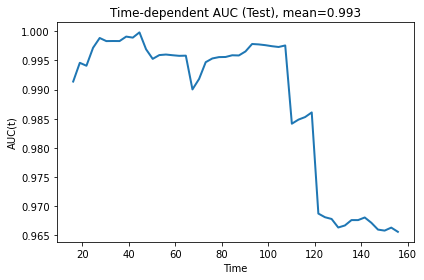

In [21]:
# optimal params
best_params = grid.best_params_

final_rsf = RandomSurvivalForest(**best_params
                                 , random_state=SEED
                                 , n_jobs=-1
                                )
final_rsf.fit(X_train_scd, y_train)

# Model save
with open(os.path.join(out, "models", "rsf_M01.pkl"), "wb") as f:
    pickle.dump(final_rsf, f)
print("Model saved. .")

# Evaluation --> X_val
risk_val = final_rsf.predict(X_val_scd)
c_val = concordance_index_censored(y_val["event"], y_val["time"], risk_val)[0]
print(f"[Validation] C-index = {c_val:.4f}")

# Evaluation --> X_test
risk_test = final_rsf.predict(X_test_scd)
c_test = concordance_index_censored(y_test["event"], y_test["time"], risk_test)[0]
print(f"[Test] C-index = {c_test:.4f}")

# Time-dependant AUC (AUC(t))
times = np.linspace(np.percentile(y_test["time"], 10),
                    np.percentile(y_test["time"], 90), 50)
auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_test, times)
plt.plot(times, auc, lw=2)
plt.xlabel("Time")
plt.ylabel("AUC(t)")
plt.title(f"Time-dependent AUC (Test), mean={mean_auc:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(out, "figs", "roc_time_auc_test.png"))
# plt.close()
plt.show()

In [ ]:
## Load dataset & Model

In [25]:
BASE_DIR = out
MODEL_PATH = os.path.join(BASE_DIR, "models", "rsf_M01.pkl")
ORN_DIR    = os.path.join(BASE_DIR, "datasets", "orn")
SCD_DIR    = os.path.join(BASE_DIR, "datasets", "scd")

with open(MODEL_PATH, "rb") as f:
    final_rsf = pickle.load(f)
print("[Loaded] Model -> final_rsf")

def _load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

X_train_ov = _load_pkl(os.path.join(ORN_DIR, "X_train_ov.pkl"))
y_train_ov = _load_pkl(os.path.join(ORN_DIR, "y_train_ov.pkl"))
X_test = _load_pkl(os.path.join(ORN_DIR, "X_test.pkl"))
y_test = _load_pkl(os.path.join(ORN_DIR, "y_test.pkl"))
X_train = _load_pkl(os.path.join(ORN_DIR, "X_train.pkl"))
y_train = _load_pkl(os.path.join(ORN_DIR, "y_train.pkl"))
X_val = _load_pkl(os.path.join(ORN_DIR, "X_val.pkl"))
y_val = _load_pkl(os.path.join(ORN_DIR, "y_val.pkl"))
print("[Loaded] ORN datasets -> X_train_ov, y_train_ov, X_test, y_test, X_train, y_train, X_val, y_val")

X_train_scd = pd.read_csv(os.path.join(SCD_DIR, "X_train_scd.csv"), index_col=0)
X_val_scd   = pd.read_csv(os.path.join(SCD_DIR, "X_val_scd.csv"),   index_col=0)
X_test_scd  = pd.read_csv(os.path.join(SCD_DIR, "X_test_scd.csv"),  index_col=0)
print("[Loaded] SCD datasets -> X_train_scd, X_val_scd, X_test_scd")

# Verify
def _shape(x):
    try:
        return x.shape
    except Exception:
        return type(x)
print("final_rsf type:", type(final_rsf))
print("X_train_ov / y_train_ov:", _shape(X_train_ov), _shape(y_train_ov))
print("X_train / y_train:", _shape(X_train), _shape(y_train))
print("X_val / y_val:", _shape(X_val), _shape(y_val))
print("X_test / y_test:", _shape(X_test), _shape(y_test))
print("SCD:", _shape(X_train_scd), _shape(X_val_scd), _shape(X_test_scd))

[Loaded] Model -> final_rsf
[Loaded] ORN datasets -> X_train_ov, y_train_ov, X_test, y_test, X_train, y_train, X_val, y_val
[Loaded] SCD datasets -> X_train_scd, X_val_scd, X_test_scd
final_rsf type: <class 'sksurv.ensemble.forest.RandomSurvivalForest'>
X_train_ov / y_train_ov: (1025, 110) (1025,)
X_train / y_train: (820, 110) (820,)
X_val / y_val: (205, 110) (205,)
X_test / y_test: (257, 110) (257,)
SCD: (820, 110) (205, 110) (257, 110)


In [23]:
def _counts_pct(series):
    """0/1 시리즈에서 0,1의 건수와 비율(%)을 dict로 반환."""
    s = pd.to_numeric(pd.Series(series).dropna(), errors="coerce")
    s = s[s.isin([0,1])]
    total = len(s)
    c1 = int((s == 1).sum())
    c0 = int((s == 0).sum())
    pct1 = (c1 / total * 100) if total else 0.0
    pct0 = (c0 / total * 100) if total else 0.0
    return {
        "N": total,
        "Pos (n)": c1, "Pos (%)": round(pct1, 2),
        "Neg (n)": c0, "Neg (%)": round(pct0, 2)
    }

def _y_event_series(y):
    """
    y가 sksurv 구조배열(y['event'], y['time']) 또는
    pandas Series/DataFrame일 때 event 시리즈를 반환.
    """
    # sksurv structured array
    if isinstance(y, np.ndarray) and y.dtype.names is not None:
        if "event" in y.dtype.names:
            return pd.Series(y["event"].astype(int))
    # pandas DataFrame에 event 컬럼이 있는 경우
    if isinstance(y, pd.DataFrame):
        for cand in ["event", "death_label", "Event", "EVENT"]:
            if cand in y.columns:
                return pd.to_numeric(y[cand], errors="coerce")
    # pandas Series인 경우 0/1이라면 그대로
    if isinstance(y, pd.Series):
        return pd.to_numeric(y, errors="coerce")
    raise ValueError("y에서 event 정보를 찾을 수 없습니다.")

def summarize_datasets_outcomes(
    Xy_dict,
    nec_col="ntety_2",
    dataset_order=("Train", "Val", "Test", "Train_ov")
):
    """
    Xy_dict: {"Train": (X_train, y_train), "Val": (X_val, y_val), ...}
    nec_col: NEC 라벨이 들어있는 X의 컬럼명 (없으면 NEC 표는 건너뜀)
    """
    rows_death, rows_nec = [], []

    for name in dataset_order:
        if name not in Xy_dict:
            continue
        X, y = Xy_dict[name]

        # --- Death/Survival (y.event 기준) ---
        try:
            ev = _y_event_series(y)
            death_stats = _counts_pct(ev)
            rows_death.append({
                "Dataset": name,
                **death_stats
            })
        except Exception:
            # event 정보를 못 찾으면 스킵
            pass

        # --- NEC (X[nec_col] 기준) ---
        if isinstance(X, pd.DataFrame) and nec_col in X.columns:
            nec_stats = _counts_pct(X[nec_col])
            rows_nec.append({
                "Dataset": name,
                **nec_stats
            })

    tbl_death = pd.DataFrame(rows_death)[
        ["Dataset", "N", "Pos (n)", "Pos (%)", "Neg (n)", "Neg (%)"]
    ].rename(columns={
        "Pos (n)": "Death (n)", "Pos (%)": "Death (%)",
        "Neg (n)": "Survival (n)", "Neg (%)": "Survival (%)"
    }).reset_index(drop=True)

    tbl_nec = None
    if rows_nec:
        tbl_nec = pd.DataFrame(rows_nec)[
            ["Dataset", "N", "Pos (n)", "Pos (%)", "Neg (n)", "Neg (%)"]
        ].rename(columns={
            "Pos (n)": "NEC+ (n)", "Pos (%)": "NEC+ (%)",
            "Neg (n)": "NEC− (n)", "Neg (%)": "NEC− (%)"
        }).reset_index(drop=True)

    return tbl_death, tbl_nec

# 이미 로드된 변수들: X_train, y_train, X_val, y_val, X_test, y_test,
# 선택적으로 X_train_ov, y_train_ov
Xy = {
    "Train":   (X_train, y_train),
    "Val":     (X_val,   y_val),
    "Test":    (X_test,  y_test),
}

death_table, nec_table = summarize_datasets_outcomes(
    Xy_dict=Xy,
    nec_col="ntety_2",
    dataset_order=("Train", "Val", "Test", "Train_ov")
)

print("=== Death / Survival ===")
print(death_table.to_string(index=False))

if nec_table is not None:
    print("\n=== NEC Positive / Negative ===")
    print(nec_table.to_string(index=False))
else:
    print("\n(NEC 표시는 생략됨: nec_col이 존재하지 않거나 어느 X에도 없습니다.)")

=== Death / Survival ===
Dataset   N  Death (n)  Death (%)  Survival (n)  Survival (%)
  Train 820        275      33.54           545         66.46
    Val 205         69      33.66           136         66.34
   Test 257         86      33.46           171         66.54

(NEC 표시는 생략됨: nec_col이 존재하지 않거나 어느 X에도 없습니다.)


In [ ]:
# Plots

In [30]:
def plot_cluster_survival(model, X, clusters, title, save_path,
                          figsize=(12, 7), dpi=150):
    """클러스터별 평균 생존함수 플롯 → PDF 저장, 범례는 아래 한 줄."""
    surv_funcs = model.predict_survival_function(X)

    # 고유 클러스터 정렬
    uniq = sorted(pd.unique(clusters.dropna()))

    # Figure/Axes
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # 각 클러스터 평균 생존함수
    for cl in uniq:
        mask = (clusters == cl).values
        if mask.sum() == 0:
            continue
        funcs = [surv_funcs[i] for i, keep in enumerate(mask) if keep]
        ts = np.unique(np.concatenate([fn.x for fn in funcs]))
        mat = np.vstack([fn(ts) for fn in funcs])
        mean_surv = mat.mean(axis=0)
        ax.step(ts, mean_surv, where="post", label=f"Cluster {cl}")

    ax.set_xlabel("Time", fontsize=11)
    ax.set_ylabel("Survival probability", fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=13)

    # 범례를 아래 1줄로
    ncol = max(1, len(uniq))
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),   # ← 이전 -0.15 에서 ↑ 가까이
        ncol=ncol,
        frameon=True,
        fontsize=10,
        handlelength=1.8,
        columnspacing=1.0,
        borderpad=0.6,
        handletextpad=0.6
    )
    fig.subplots_adjust(bottom=0.15)

    # === PDF 저장 (os.path만 사용) ===
    # 확장자 강제로 .pdf
    base, ext = os.path.splitext(save_path)
    pdf_path = base + ".pdf"
    # 디렉토리 생성
    os.makedirs(os.path.dirname(pdf_path), exist_ok=True)
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

    plt.show()

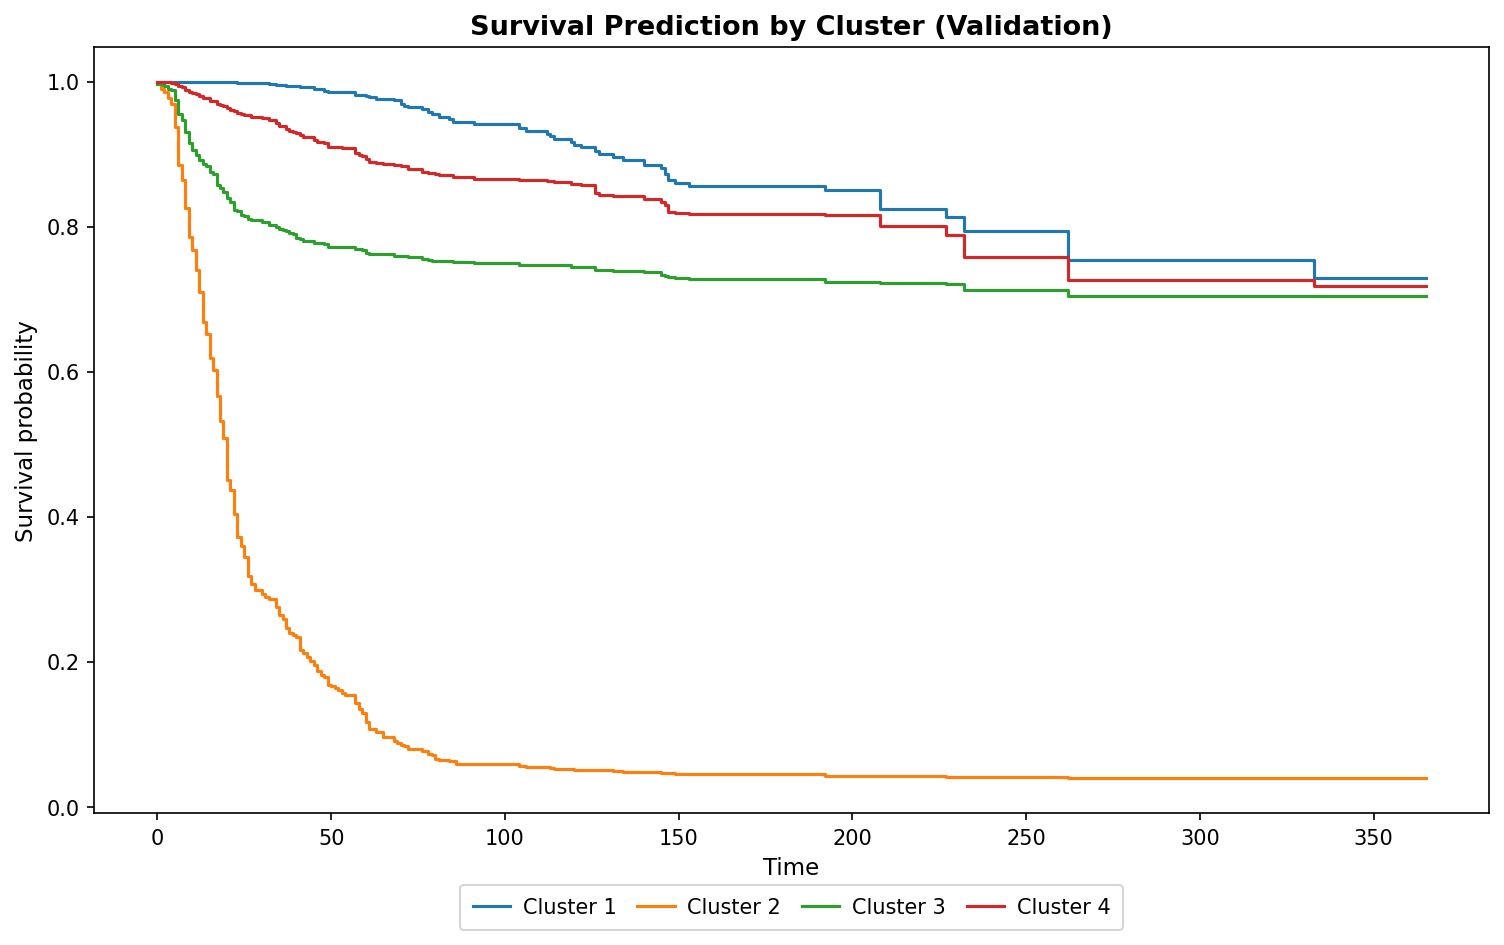

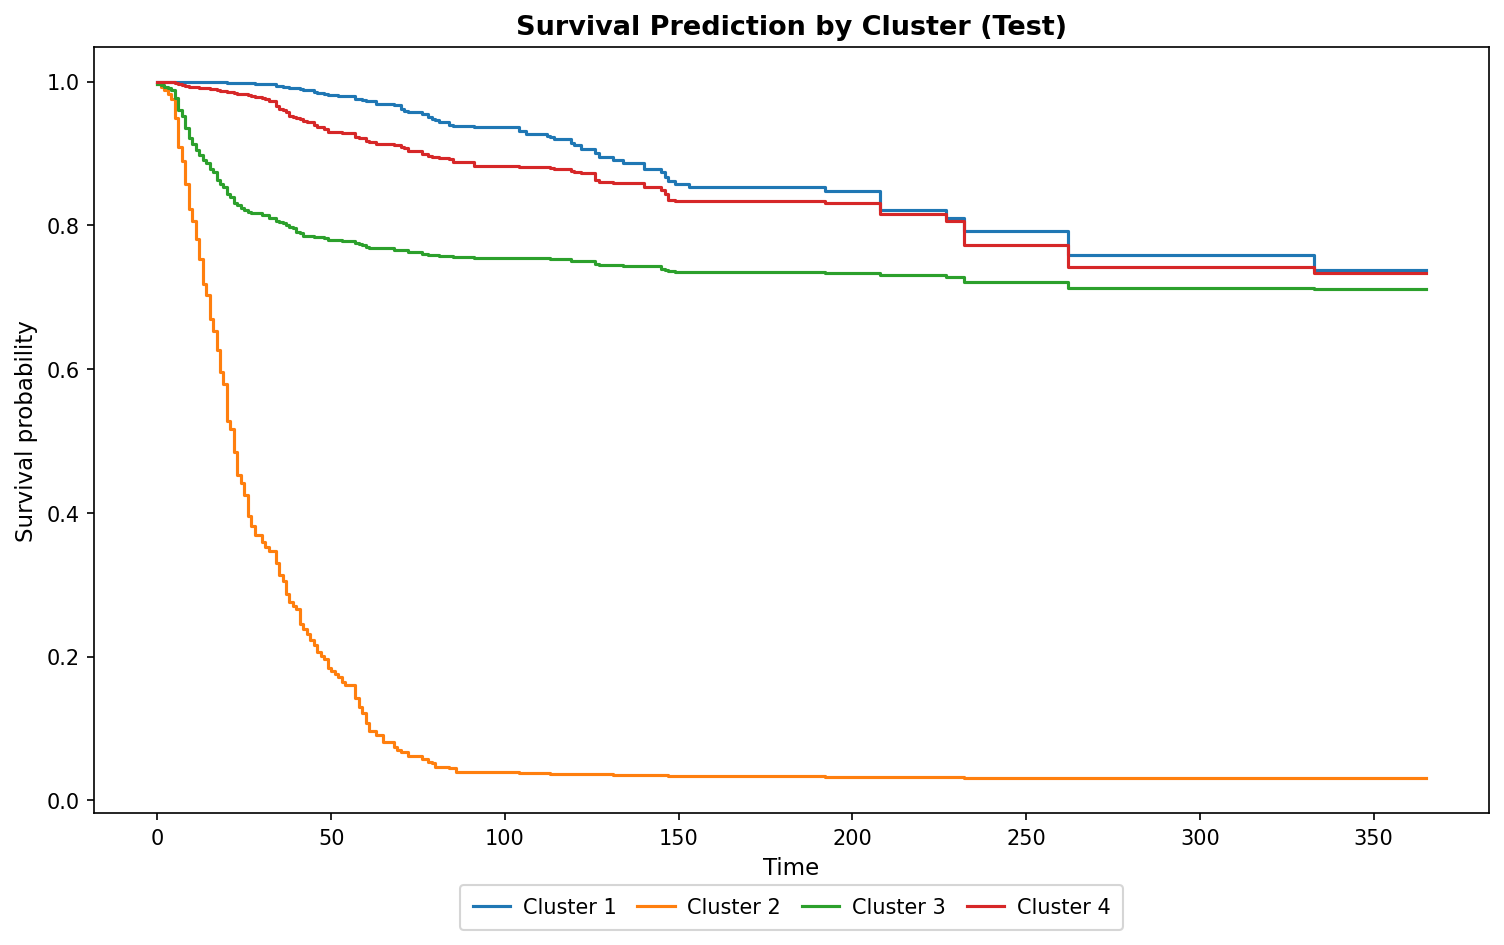

In [25]:
# Validation clusters
if cluster_series is not None:
    plot_cluster_survival(
        final_rsf,
        X_val_scd,
        cluster_series.loc[X_val.index],
        "Survival Prediction by Cluster (Validation)",
        os.path.join(out, "figs", "survival_by_cluster_val.pdf")
    )

# Test clusters
if cluster_series is not None:
    plot_cluster_survival(
        final_rsf,
        X_test_scd,
        cluster_series.loc[X_test.index],
        "Survival Prediction by Cluster (Test)",
        os.path.join(out, "figs", "survival_by_cluster_test.pdf")
    )

In [37]:
def build_feature_name_mapper(df_dic: pd.DataFrame,
                              key_col: str = "col_name",
                              feat_col: str = "feature_name") -> dict:
    """df_dic[key_col] → df_dic[feat_col] 매핑 딕셔너리 생성."""
    dic = df_dic[[key_col, feat_col]].dropna(subset=[key_col]).copy()
    dic[key_col]  = dic[key_col].astype(str).str.strip()
    dic[feat_col] = dic[feat_col].astype(str).str.strip()
    return dic.set_index(key_col)[feat_col].to_dict()

def apply_feature_name_mapper(X: pd.DataFrame,
                              mapper: dict,
                              drop_sum_other: bool = True,
                              make_unique: bool = True) -> pd.DataFrame:
    """
    - (선택) 'Sum of Other features' 컬럼 제거
    - mapper에 따라 컬럼명만 변경(매핑 없으면 원래 이름 유지)
    - (선택) 매핑으로 중복 이름 생기면 유니크하게 후처리
    """
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X는 pandas.DataFrame이어야 합니다.")

    X2 = X.copy()
    if drop_sum_other and "Sum of Other features" in X2.columns:
        X2 = X2.drop(columns=["Sum of Other features"])

    # rename (매핑 없는 건 그대로)
    X2 = X2.rename(columns=lambda c: mapper.get(str(c), str(c)))

    if make_unique and len(set(X2.columns)) != len(X2.columns):
        seen, out = {}, []
        for c in X2.columns:
            if c not in seen:
                seen[c] = 1
                out.append(c)
            else:
                out.append(f"{c}__{seen[c]}")  # 뒤에 번호 붙이기
                seen[c] += 1
        X2.columns = out

    return X2

df_dic = pd.read_excel(os.path.join(colmap, "list_4_sort(features_EN).xlsx"))[
    ["col_name","feature_name"]
]
name_mapper = build_feature_name_mapper(df_dic)

In [38]:
def plot_shap_beeswarm_pdf_for_rsf(
    model,
    X_orig: pd.DataFrame,
    display_name_mapper: dict = None,
    top_n: int = 20,
    save_path: str = "shap_beeswarm.pdf",
    background_size: int = 200,
    random_state: int = 42,
    figsize=(12, 8),
    drop_from_plot: set = None,
    verbose: bool = True,
    show_progress: bool = True,
    title: str = None,
    title_fontsize: int = 14,
    title_pad: int = 16,
):
    t0 = time.perf_counter()
    def log(msg):
        if verbose:
            print(f"[SHAP] {msg}")

    if not isinstance(X_orig, pd.DataFrame):
        raise TypeError("X_orig는 pandas.DataFrame이어야 합니다.")

    log("Start")
    rng = np.random.default_rng(random_state)
    if len(X_orig) > background_size:
        bg_idx = rng.choice(len(X_orig), size=background_size, replace=False)
        X_bg = X_orig.iloc[bg_idx].copy()
        log(f"Background sampled: {len(X_bg)}/{len(X_orig)}")
    else:
        X_bg = X_orig.copy()
        log(f"Background uses full data: {len(X_bg)}")

    def predict_risk(x_array):
        df_in = pd.DataFrame(x_array, columns=X_orig.columns)
        return model.predict(df_in)

    log("Building explainer…")
    explainer = shap.Explainer(predict_risk, X_bg, seed=random_state)
    log("Computing SHAP values…")
    sv = explainer(X_orig, silent=not show_progress)

    # 표시 이름
    if display_name_mapper is None:
        display_names = list(X_orig.columns)
    else:
        display_names = [display_name_mapper.get(str(c), str(c)) for c in X_orig.columns]

    # 제외 목록(표시 이름 기준)
    keep_idx = list(range(len(display_names)))
    if drop_from_plot:
        drop_from_plot = set(drop_from_plot)
        keep_idx = [i for i, nm in enumerate(display_names) if nm not in drop_from_plot]

    # 상위 n개만 선택 → “Sum of other” 제거
    mean_abs = np.abs(sv.values).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]
    order = [i for i in order if i in keep_idx]
    sel_idx = order[:int(top_n)]
    sel_names = [display_names[i] for i in sel_idx]

    sv_disp = sv[:, sel_idx]
    sv_disp.feature_names = sel_names

    # 플롯
    plt.figure(figsize=figsize)
    shap.plots.beeswarm(sv_disp, max_display=len(sel_idx), show=False)
    if title:
        plt.title(title, fontsize=title_fontsize, pad=title_pad)  # ★ pad 적용

    # 저장
    base, _ = os.path.splitext(save_path)
    pdf_path = base + ".pdf"
    os.makedirs(os.path.dirname(pdf_path) or ".", exist_ok=True)

    # 타이틀이 안 잘리게 하면서도 간격 유지: top을 살짝만 남겨둠
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
    plt.show()

    log(f"Saved PDF → {pdf_path}")
    log(f"Done in {time.perf_counter()-t0:.2f}s")
    return {"pdf_path": pdf_path, "shap_values": sv_disp, "explainer": explainer}

[SHAP] Start
[SHAP] Background sampled: 200/257
[SHAP] Building explainer…
[SHAP] Computing SHAP values…


PermutationExplainer explainer: 258it [06:02,  1.45s/it]                         


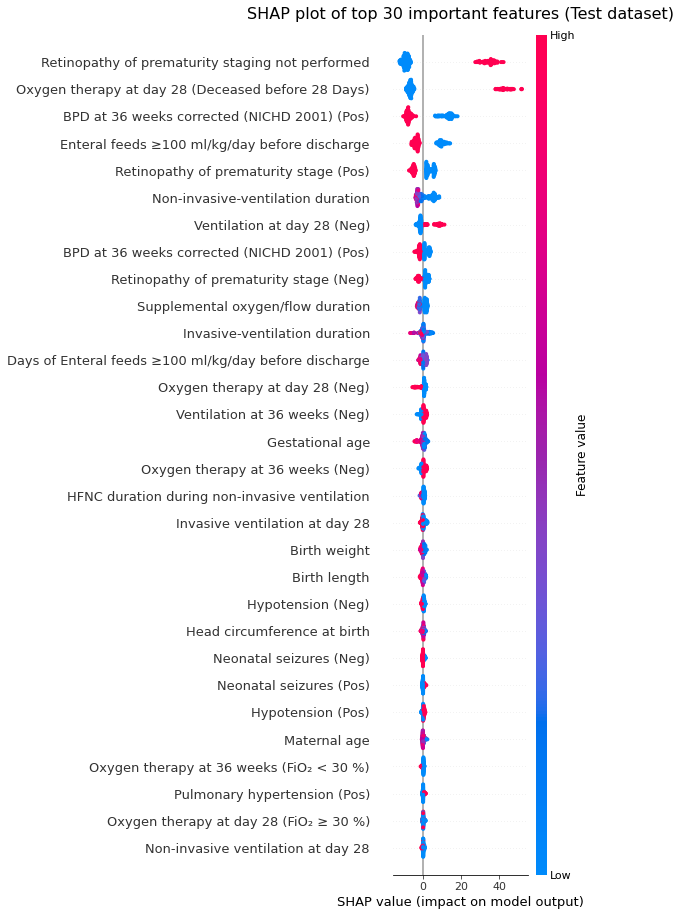

[SHAP] Saved PDF → /media/bami/JHA/24-07_nedis/KNN/Clustering/P1_NEC/Surv/figs/shap_beeswarm_test.pdf
[SHAP] Done in 363.92s
[SHAP] Start
[SHAP] Background sampled: 200/205
[SHAP] Building explainer…
[SHAP] Computing SHAP values…


PermutationExplainer explainer: 206it [05:22,  1.62s/it]                         


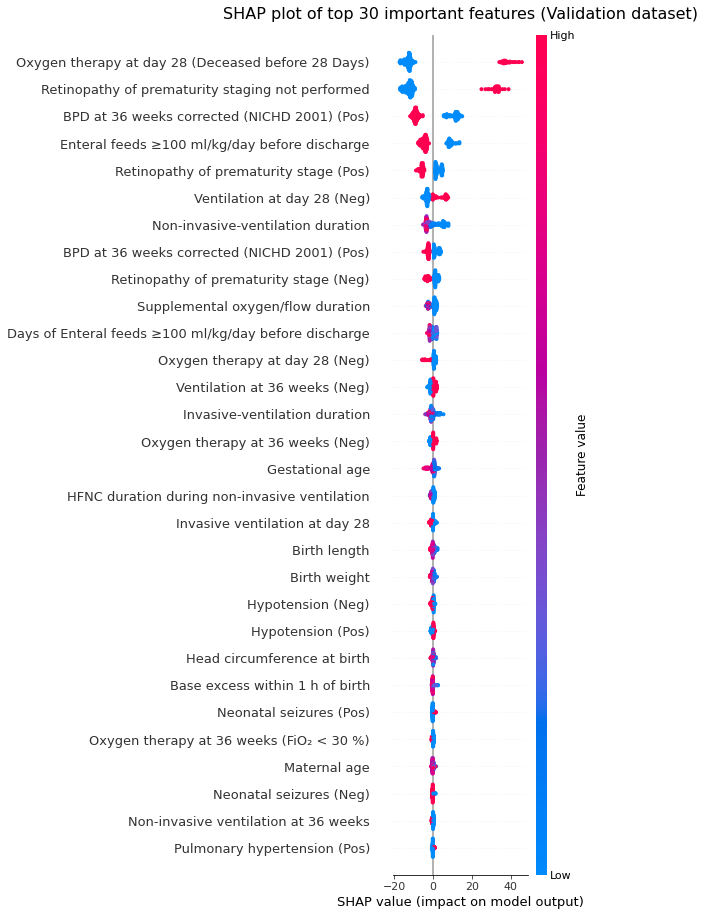

[SHAP] Saved PDF → /media/bami/JHA/24-07_nedis/KNN/Clustering/P1_NEC/Surv/figs/shap_beeswarm_val.pdf
[SHAP] Done in 323.87s


In [33]:
feat_n = 30
drop_set = {"Sum of Other features"}

# Apply to Test set
res_test = plot_shap_beeswarm_pdf_for_rsf(
    model=final_rsf,
    X_orig=X_test_scd,
    display_name_mapper=name_mapper,
    top_n=feat_n,
    save_path=os.path.join(out, "figs", "shap_beeswarm_test.pdf"),
    figsize=(14, 12),
    drop_from_plot=drop_set,
    title=f"SHAP plot of top {feat_n} important features (Test dataset)",
    title_fontsize=16,
    title_pad=16
)

# Apply to Validation set
res_val = plot_shap_beeswarm_pdf_for_rsf(
    model=final_rsf,
    X_orig=X_val_scd,
    display_name_mapper=name_mapper,
    top_n=feat_n,
    save_path=os.path.join(out, "figs", "shap_beeswarm_val.pdf"),
    figsize=(14, 12),
    drop_from_plot=drop_set,
    title=f"SHAP plot of top {feat_n} important features (Validation dataset)",
    title_fontsize=16,
    title_pad=16
)

PermutationExplainer explainer: 4072it [26:19,  2.57it/s]                          


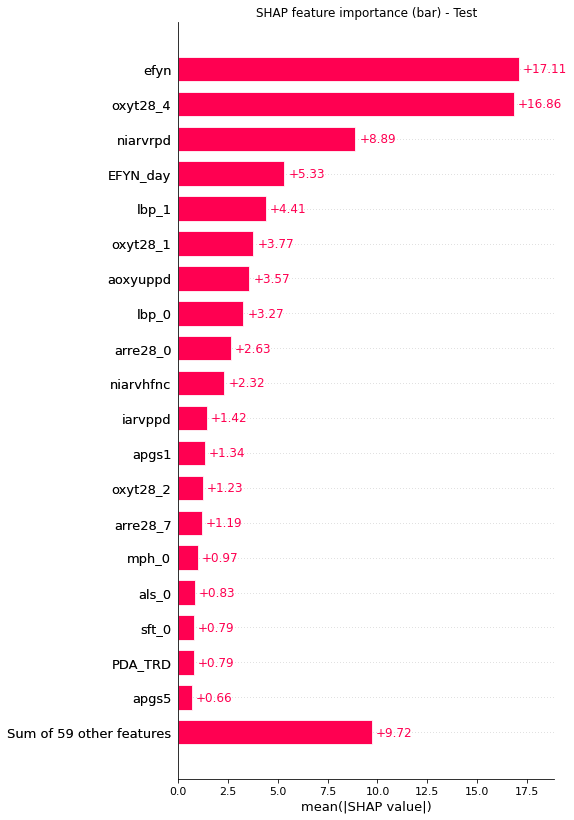

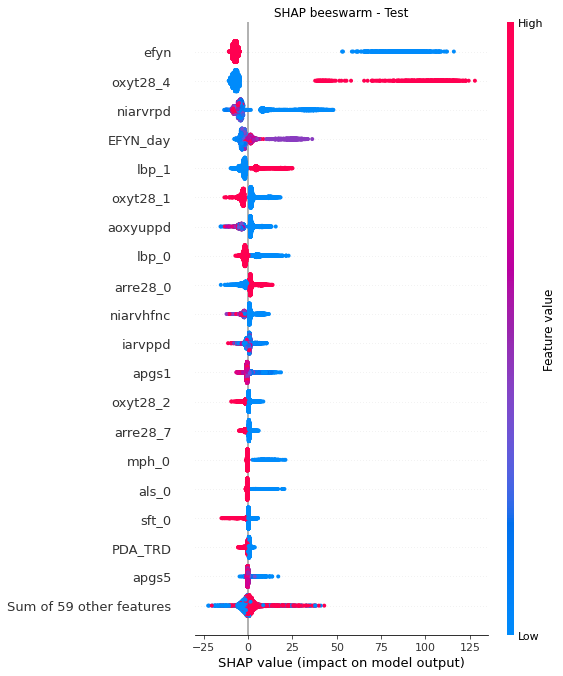

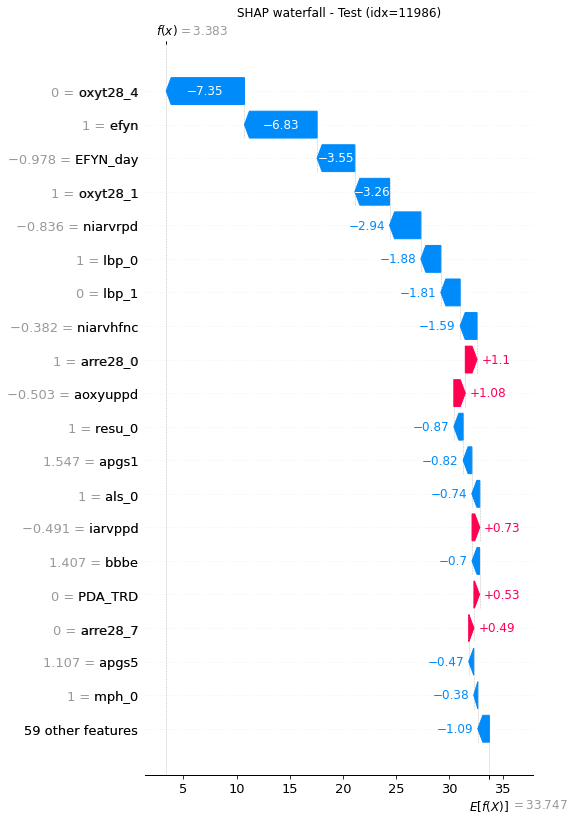

In [71]:
## SHAP value plotting

model_path = os.path.join(out, "models", "rsf_M01.pkl")
fig_dir    = os.path.join(out, "figures")

# SAVE
with open(model_path, "rb") as f:
    rsf = pickle.load(f)

# data
bg_size = min(200, len(X_train_scd))
background = X_train_scd.sample(n=bg_size, random_state=SEED)

# Compose 'Explainer'
explainer = shap.Explainer(lambda X: rsf.predict(X), background)

# calc SHAP values
shap_values_test = explainer(X_test_scd)

# (A) Bar plot (상위 20개)
plt.figure()
shap.plots.bar(shap_values_test, max_display=30, show=False)
plt.title("SHAP feature importance (bar) - Test")
plt.tight_layout()
# plt.savefig(os.path.join(fig_dir, "shap_bar_test.png"), dpi=150)
plt.show()

# (B) Beeswarm (상위 20개, 값의 분포)
plt.figure()
shap.plots.beeswarm(shap_values_test, max_display=30, show=False)
plt.title("SHAP beeswarm - Test")
plt.tight_layout()
# plt.savefig(os.path.join(fig_dir, "shap_beeswarm_test.png"), dpi=150)
plt.show()

# (C) 개별 샘플 Waterfall (임의 index 하나 선택)
sample_idx = X_test_scd.index[0]
shap_single = shap_values_test[X_test_scd.index.get_loc(sample_idx)]
plt.figure()
shap.plots.waterfall(shap_single, max_display=30, show=False)
plt.title(f"SHAP waterfall - Test (idx={sample_idx})")
plt.tight_layout()
# plt.savefig(os.path.join(fig_dir, f"shap_waterfall_test_idx{sample_idx}.png"), dpi=150)
plt.show()

In [ ]:
fig_dir  = os.path.join(out, "figs"); os.makedirs(fig_dir, exist_ok=True)
tab_dir  = os.path.join(out, "tables");  os.makedirs(tab_dir, exist_ok=True)


# 1) Impurity-based (MDI) importance
fi = pd.Series(final_rsf.feature_importances_, index=X_train_scd.columns)
fi = fi.sort_values(ascending=False)

# SAVE
fi.to_csv(os.path.join(tab_dir, "feature_importance_mdi.csv"))

# Plotting
topN = 30
plt.figure(figsize=(7, max(3, topN*0.3)))
fi.head(topN).iloc[::-1].plot(kind="barh")
plt.xlabel("MDI importance")
plt.title(f"RSF Feature Importance (MDI) - Top {topN}")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, f"feat_importance_mdi_top{topN}.png"), dpi=150)
plt.close()

print("[MDI] saved:",
      os.path.join(tab_dir, "feature_importance_mdi.csv"),
      os.path.join(fig_dir, f"feat_importance_mdi_top{topN}.png"))

# 2) Permutation importance (C-index 기반)
#    - Validation 세트 기준 권장

# Grid/평가 때 썼던 C-index scorer 재사용
def cindex_scorer(estimator, X, y):
    from sksurv.metrics import concordance_index_censored
    risk = estimator.predict(X)
    return concordance_index_censored(y["event"], y["time"], risk)[0]

perm = permutation_importance(
    final_rsf,
    X_val_scd,
    y_val,
    n_repeats=30,
    random_state=SEED,
    scoring=cindex_scorer,
    n_jobs=-1
)

pi_mean = pd.Series(perm.importances_mean, index=X_val_scd.columns)
pi_std  = pd.Series(perm.importances_std,  index=X_val_scd.columns)
pi = pd.DataFrame({"perm_importance_mean": pi_mean, "perm_importance_std": pi_std})
pi = pi.sort_values("perm_importance_mean", ascending=False)

# 저장
pi.to_csv(os.path.join(tab_dir, "feature_importance_permutation_val.csv"))

# 플롯 (Top 20)
plt.figure(figsize=(7, max(3, topN*0.3)))
pi.head(topN).iloc[::-1]["perm_importance_mean"].plot(kind="barh")
plt.xlabel("Permutation importance (Δ C-index)")
plt.title(f"RSF Permutation Importance (Validation) - Top {topN}")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, f"feat_importance_perm_val_top{topN}.png"), dpi=150)
plt.close()

In [ ]:
## Making Figure 3

In [2]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival
from scipy.stats import norm
from PIL import Image

In [3]:
df0 = pd.read_csv(f'{ipt}/KNN_df_combined.csv')
df0.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
df0.set_index('idx_code', inplace=True)

cluster_series_all = df0['Cluster_Labels'].copy()
cluster_series_test = cluster_series_all.reindex(X_test_scd.index)

# 혹시 누락이 있으면 확인
miss = cluster_series_test.isna().sum()
if miss:
    print(f"[WARN] missing cluster labels in test: {miss}")

mask = (cluster_series_test.values == cl)
t, s = kaplan_meier_estimator(y_test["event"][mask], y_test["time"][mask])


NameError: name 'ipt' is not defined

In [67]:
# cluster_palette = {
#     1: '#1f77b4',  # blue
#     2: '#ff7f0e',  # orange
#     3: '#2ca02c',  # green
#     4: '#d62728',  # red
#     5: "#0072B2",  # blue
# #     5: '#9467bd',  # purple
#     6: "#D55E00",  # vermillion
# #     6: '#8c564b',  # brown
#     7: '#e377c2',  # pink
# #     8: '#7f7f7f',  # gray
#     8: "#009E73",  # green
# }

cluster_palette = {
    1: "#0072B2",  # blue
    2: "#E69F00",  # orange
    3: "#009E73",  # green
    4: "#D55E00",  # vermillion
    5: "#CC79A7",  # purple
    6: "#56B4E9",  # sky blue
    7: "#F0E442",  # yellow
    8: "#332288",  # navy
}



def build_palette(base_palette: dict, labels):
    labels = sorted(pd.unique(pd.Series(labels).dropna()))
    final = {}
    cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    used = set(base_palette.values()) if base_palette else set()
    i = 0
    for lab in labels:
        if base_palette and (lab in base_palette):
            final[lab] = base_palette[lab]
        else:
            while i < len(cycle) and cycle[i] in used:
                i += 1
            col = cycle[i % len(cycle)]
            final[lab] = col
            used.add(col); i += 1
    return final

def mean_surv_by_cluster_rsf(model, X, clusters):
    surv_funcs = model.predict_survival_function(X)
    clusters = pd.Series(clusters)
    uniq = sorted(pd.unique(clusters.dropna()))
    out = {}
    for cl in uniq:
        m = (clusters.values == cl)
        if m.sum() == 0:
            continue
        funcs = [surv_funcs[i] for i, keep in enumerate(m) if keep]
        ts = np.unique(np.concatenate([fn.x for fn in funcs]))
        mat = np.vstack([fn(ts) for fn in funcs])
        out[cl] = (ts, mat.mean(axis=0))
    return out

def _logrank_p_global(y, clusters):
    groups = pd.Series(clusters).astype(str).values
    res = compare_survival(y, groups)

    if hasattr(res, "p_value"):
        return float(res.p_value)

    if isinstance(res, tuple):
        if len(res) >= 2 and np.isscalar(res[1]):
            return float(res[1])

    raise TypeError(f"Unexpected compare_survival return type: {type(res)} / value: {res}")

def km_band(time, event, alpha=0.05, method="log-log", eps=1e-12):
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=bool)

    t, s = kaplan_meier_estimator(event, time)

    order = np.argsort(time)
    time_s = time[order]
    event_s = event[order]

    uniq_times = np.unique(time_s)
    n_at_risk = np.array([(time_s >= ut).sum() for ut in uniq_times], dtype=float)
    d_events  = np.array([(event_s & (time_s == ut)).sum() for ut in uniq_times], dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        inc = d_events / (n_at_risk * (n_at_risk - d_events))
        inc[~np.isfinite(inc)] = 0.0
    cum = np.cumsum(inc)

    idx = np.searchsorted(uniq_times, t)
    idx = np.clip(idx, 0, len(cum)-1)
    var_s = (s ** 2) * cum[idx]
    se_s = np.sqrt(np.maximum(var_s, 0.0))

    z = norm.ppf(1 - alpha/2)

    if method == "plain":
        lo = np.clip(s - z * se_s, 0, 1)
        hi = np.clip(s + z * se_s, 0, 1)
        return t, s, lo, hi

    s_clip = np.clip(s, eps, 1 - eps)
    with np.errstate(divide="ignore", invalid="ignore"):
        se_ll = se_s / (np.abs(np.log(s_clip)) * s_clip + eps)
    ll = np.log(-np.log(s_clip))
    lo = np.exp(-np.exp(ll + z * se_ll))
    hi = np.exp(-np.exp(ll - z * se_ll))
    lo = np.clip(lo, 0, 1); hi = np.clip(hi, 0, 1)
    return t, s, lo, hi

def plot_fig3_km_rsf_test_composite(
    final_rsf,
    y_test,
    X_test_scd,
    ipt,                    # folder containing KNN_df_combined.csv
    out_dir,
    dpi=600,
    to_cmyk=True,
    panel_A="A.", panel_B="B.",
    cluster_col="Cluster_Labels",
    palette_base=cluster_palette,
    km_band_alpha=0.18,      # band 투명도
    km_ci_alpha=0.05,        # 95% CI
    x_max=400                # 고정 x축 최대값
):
    os.makedirs(out_dir, exist_ok=True)

    df0 = pd.read_csv(os.path.join(ipt, "KNN_df_combined.csv"))
    if "Unnamed: 0" in df0.columns:
        df0 = df0.rename(columns={"Unnamed: 0": "idx_code"})
    if "idx_code" not in df0.columns:
        raise KeyError("KNN_df_combined.csv에 idx_code(또는 Unnamed: 0)가 없어.")
    df0 = df0.set_index("idx_code")

    if cluster_col not in df0.columns:
        raise KeyError(f"KNN_df_combined.csv에 '{cluster_col}' 컬럼이 없어.")

    df0.index = df0.index.astype(str)
    X_test_scd = X_test_scd.copy()
    X_test_scd.index = X_test_scd.index.astype(str)

    clusters_test = df0[cluster_col].reindex(X_test_scd.index)
    miss = int(clusters_test.isna().sum())
    if miss:
        miss_ids = clusters_test[clusters_test.isna()].index[:10].tolist()
        raise ValueError(f"[ERROR] test index 중 cluster 라벨 누락 {miss}개. 예: {miss_ids}")

    uniq = sorted(pd.unique(clusters_test.dropna()))
    palette = build_palette(palette_base, uniq)

    p_global = _logrank_p_global(y_test, clusters_test.values)
    p_txt = "p < 0.001" if p_global < 0.001 else f"p = {p_global:.3f}"

    handles = [Line2D([0],[0], color=palette.get(cl, "C0"), lw=2) for cl in uniq]
    labels  = [f"Cluster {cl}" for cl in uniq]

    fig, (axA, axB) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # ===== A) KM (Test) + CI band (관측된 구간만) =====
    for cl in uniq:
        m = (clusters_test.values == cl)
        if m.sum() == 0:
            continue

        t, s, lo, hi = km_band(
            time=y_test["time"][m],
            event=y_test["event"][m],
            alpha=km_ci_alpha,
            method="log-log"
        )

        col = palette.get(cl, "C0")
        axA.step(t, s, where="post", color=col, lw=1.8)
        axA.fill_between(t, lo, hi, step="post", color=col, alpha=km_band_alpha, linewidth=0)

    axA.set_title("Kaplan–Meier by Cluster", fontweight="bold")
    axA.set_xlabel("Time (days)")                 # << added
    axA.set_ylabel("Survival probability (%)")
    axA.set_ylim(0, 1)
    axA.set_xlim(0, x_max)

    axA.text(0.99, 0.02, f"Log-rank (global) {p_txt}",
             transform=axA.transAxes, ha="right", va="bottom", fontsize=9)

    axA.text(-0.08, 1.02, panel_A, transform=axA.transAxes,
             ha="left", va="bottom", fontsize=14, fontweight="bold", clip_on=False)

    # ===== B) RSF predicted (Test) =====
    rsf_means = mean_surv_by_cluster_rsf(final_rsf, X_test_scd, clusters_test)
    for cl in uniq:
        if cl not in rsf_means:
            continue
        ts, ms = rsf_means[cl]
        axB.step(ts, ms, where="post", color=palette.get(cl, "C0"), lw=1.8)

    axB.set_title("RSF (Test) survival by Cluster", fontweight="bold")
    axB.set_xlabel("Time (days)")
    axB.set_ylabel("Survival probability (%)")
    axB.set_ylim(0, 1)
    axB.set_xlim(0, x_max)

    axB.text(-0.08, 1.02, panel_B, transform=axB.transAxes,
             ha="left", va="bottom", fontsize=14, fontweight="bold", clip_on=False)

    # y-axis 0–100%
    fmt = FuncFormatter(lambda v, _: f"{v*100:.0f}%")
    for ax in (axA, axB):
        ax.set_yticks(np.linspace(0, 1, 6))
        ax.yaxis.set_major_formatter(fmt)

        # x-axis ticks: 0–400 by 50
        ax.xaxis.set_major_locator(MultipleLocator(50))
        ax.set_xticks(np.arange(0, x_max + 1, 50))

    # legend: one row
#     fig.legend(handles, labels, loc="lower center",
#                ncol=len(labels), frameon=True, fontsize=10)
    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),          # ↓/↑ 위치 미세조정 (필요시 0.00~0.05)
        ncol=len(labels),                    # 한 줄 유지
        frameon=True,
        fontsize=10,
        handlelength=1.2,                    # ← 줄이기 (기본보다 짧게)
        handletextpad=0.4,                   # ← 줄이기
        columnspacing=0.8,                   # ← 줄이기 (핵심)
        borderpad=0.45                       # ← 줄이기 (프레임 여백)
    )

    # reduce gap between A and B
    fig.subplots_adjust(bottom=0.11, top=0.95, hspace=0.18, left=0.12)

    rgb_path = os.path.join(out_dir, "Figure3_KM_RSF_Test_RGB.tif")
    fig.savefig(rgb_path, format="tiff", dpi=dpi, bbox_inches="tight",
                pil_kwargs={"compression": "tiff_lzw"})

    plt.show()
    plt.close(fig)

    if to_cmyk:
        Image.MAX_IMAGE_PIXELS = None
        cmyk_path = os.path.join(out_dir, "Figure3_KM_RSF_Test_CMYK.tif")
        Image.open(rgb_path).convert("CMYK").save(
            cmyk_path, dpi=(dpi, dpi), compression="tiff_lzw"
        )
        return cmyk_path

    return rgb_path

Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.


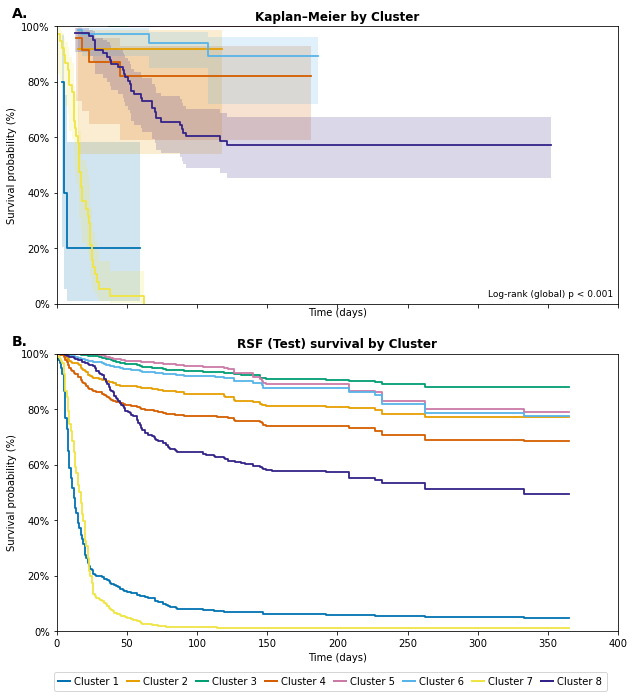

[Saved] /media/bami/JHA/24-07_nedis/KNN/Clustering/P1_NEC/Surv/figs/Figure3_KM_RSF_Test_CMYK.tif


In [68]:
fig3_path = plot_fig3_km_rsf_test_composite(
    final_rsf=final_rsf,
    y_test=y_test,
    X_test_scd=X_test_scd,
    ipt=ipt,
    out_dir=os.path.join(BASE_DIR, "figs"),
    dpi=600,
    to_cmyk=True,
    panel_A="A.", panel_B="B.",
    palette_base=cluster_palette,
    km_band_alpha=0.18,
    km_ci_alpha=0.05,
    x_max=400
)
print("[Saved]", fig3_path)

In [57]:
cluster_palette = {
    1: '#1f77b4',  # blue
    2: '#ff7f0e',  # orange
    3: '#2ca02c',  # green
    4: '#d62728',  # red
    5: "#0072B2",  # blue (adjusted)
    6: "#D55E00",  # vermillion (adjusted)
    7: '#e377c2',  # pink
    8: "#009E73",  # green (adjusted)
}

def build_palette(base_palette: dict, labels):
    labels = sorted(pd.unique(pd.Series(labels).dropna()))
    final = {}
    cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    used = set(base_palette.values()) if base_palette else set()
    i = 0
    for lab in labels:
        if base_palette and (lab in base_palette):
            final[lab] = base_palette[lab]
        else:
            while i < len(cycle) and cycle[i] in used:
                i += 1
            col = cycle[i % len(cycle)]
            final[lab] = col
            used.add(col); i += 1
    return final

def mean_surv_by_cluster_rsf(model, X, clusters):
    surv_funcs = model.predict_survival_function(X)
    clusters = pd.Series(clusters)
    uniq = sorted(pd.unique(clusters.dropna()))
    out = {}
    for cl in uniq:
        m = (clusters.values == cl)
        if m.sum() == 0:
            continue
        funcs = [surv_funcs[i] for i, keep in enumerate(m) if keep]
        ts = np.unique(np.concatenate([fn.x for fn in funcs]))
        mat = np.vstack([fn(ts) for fn in funcs])
        out[cl] = (ts, mat.mean(axis=0))
    return out

def _logrank_p_global(y, clusters):
    groups = pd.Series(clusters).astype(str).values
    res = compare_survival(y, groups)
    if hasattr(res, "p_value"):
        return float(res.p_value)
    if isinstance(res, tuple):
        if len(res) >= 2 and np.isscalar(res[1]):
            return float(res[1])
    raise TypeError(f"Unexpected compare_survival return type: {type(res)} / value: {res}")

def _extend_to_xmax(t, *ys, x_max=400.0):
    """
    step curve가 마지막 시간까지만 그려져 '멈춰' 보이는 문제 해결:
    마지막 값을 x_max까지 수평 연장하기 위해 (x_max, last_y) 점을 추가.
    """
    t = np.asarray(t, dtype=float)
    if t.size == 0:
        return (np.array([0.0, x_max]),) + tuple(np.array([np.nan, np.nan]) for _ in ys)

    if t[-1] < x_max:
        t2 = np.append(t, x_max)
        out = []
        for y in ys:
            y = np.asarray(y, dtype=float)
            out.append(np.append(y, y[-1]))
        return (t2, *out)
    return (t, *ys)

def km_band(time, event, alpha=0.05, method="log-log", eps=1e-12):
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=bool)

    # KM estimate
    t, s = kaplan_meier_estimator(event, time)

    # Greenwood components
    order = np.argsort(time)
    time_s = time[order]
    event_s = event[order]

    uniq_times = np.unique(time_s)
    n_at_risk = np.array([(time_s >= ut).sum() for ut in uniq_times], dtype=float)
    d_events  = np.array([(event_s & (time_s == ut)).sum() for ut in uniq_times], dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        inc = d_events / (n_at_risk * (n_at_risk - d_events))
        inc[~np.isfinite(inc)] = 0.0
    cum = np.cumsum(inc)

    idx = np.searchsorted(uniq_times, t)
    idx = np.clip(idx, 0, len(cum)-1)
    var_s = (s ** 2) * cum[idx]
    se_s = np.sqrt(np.maximum(var_s, 0.0))

    z = norm.ppf(1 - alpha/2)

    if method == "plain":
        lo = np.clip(s - z * se_s, 0, 1)
        hi = np.clip(s + z * se_s, 0, 1)
        return t, s, lo, hi

    s_clip = np.clip(s, eps, 1 - eps)
    with np.errstate(divide="ignore", invalid="ignore"):
        se_ll = se_s / (np.abs(np.log(s_clip)) * s_clip + eps)
    ll = np.log(-np.log(s_clip))
    lo = np.exp(-np.exp(ll + z * se_ll))
    hi = np.exp(-np.exp(ll - z * se_ll))
    lo = np.clip(lo, 0, 1); hi = np.clip(hi, 0, 1)
    return t, s, lo, hi

def plot_fig3_km_rsf_test_composite(
    final_rsf,
    y_test,
    X_test_scd,
    ipt,
    out_dir,
    dpi=600,
    to_cmyk=True,
    panel_A="A.", panel_B="B.",
    cluster_col="Cluster_Labels",
    palette_base=cluster_palette,
    km_band_alpha=0.18,
    km_ci_alpha=0.05,
    x_max=400
):
    os.makedirs(out_dir, exist_ok=True)

    df0 = pd.read_csv(os.path.join(ipt, "KNN_df_combined.csv"))
    if "Unnamed: 0" in df0.columns:
        df0 = df0.rename(columns={"Unnamed: 0": "idx_code"})
    if "idx_code" not in df0.columns:
        raise KeyError("KNN_df_combined.csv에 idx_code(또는 Unnamed: 0)가 없어.")
    df0 = df0.set_index("idx_code")

    if cluster_col not in df0.columns:
        raise KeyError(f"KNN_df_combined.csv에 '{cluster_col}' 컬럼이 없어.")

    df0.index = df0.index.astype(str)
    X_test_scd = X_test_scd.copy()
    X_test_scd.index = X_test_scd.index.astype(str)

    clusters_test = df0[cluster_col].reindex(X_test_scd.index)
    miss = int(clusters_test.isna().sum())
    if miss:
        miss_ids = clusters_test[clusters_test.isna()].index[:10].tolist()
        raise ValueError(f"[ERROR] test index 중 cluster 라벨 누락 {miss}개. 예: {miss_ids}")

    uniq = sorted(pd.unique(clusters_test.dropna()))
    palette = build_palette(palette_base, uniq)

    p_global = _logrank_p_global(y_test, clusters_test.values)
    p_txt = "p < 0.001" if p_global < 0.001 else f"p = {p_global:.3f}"

    handles = [Line2D([0],[0], color=palette.get(cl, "C0"), lw=2) for cl in uniq]
    labels  = [f"Cluster {cl}" for cl in uniq]

    fig, (axA, axB) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # ===== A) KM (Test) + CI band =====
    for cl in uniq:
        m = (clusters_test.values == cl)
        if m.sum() == 0:
            continue

        t, s, lo, hi = km_band(
            time=y_test["time"][m],
            event=y_test["event"][m],
            alpha=km_ci_alpha,
            method="log-log"
        )

        # <<< 핵심: 400일까지 수평 연장
        t, s, lo, hi = _extend_to_xmax(t, s, lo, hi, x_max=float(x_max))

        col = palette.get(cl, "C0")
        axA.step(t, s, where="post", color=col, lw=1.8)
        axA.fill_between(t, lo, hi, step="post", color=col, alpha=km_band_alpha, linewidth=0)

    axA.set_title("Kaplan–Meier by Cluster", fontweight="bold")
    axA.set_ylabel("Survival probability (%)")
    axA.set_ylim(0, 1)
    axA.set_xlim(0, x_max)

    axA.text(0.99, 0.02, f"Log-rank (global) {p_txt}",
             transform=axA.transAxes, ha="right", va="bottom", fontsize=9)

    axA.text(-0.08, 1.02, panel_A, transform=axA.transAxes,
             ha="left", va="bottom", fontsize=14, fontweight="bold", clip_on=False)

    # ===== B) RSF predicted (Test) =====
    rsf_means = mean_surv_by_cluster_rsf(final_rsf, X_test_scd, clusters_test)
    for cl in uniq:
        if cl not in rsf_means:
            continue
        ts, ms = rsf_means[cl]

        # <<< 핵심: 400일까지 수평 연장
        ts, ms = _extend_to_xmax(ts, ms, x_max=float(x_max))

        axB.step(ts, ms, where="post", color=palette.get(cl, "C0"), lw=1.8)

    axB.set_title("RSF (Test) survival by Cluster", fontweight="bold")
    axB.set_xlabel("Time (days)")
    axB.set_ylabel("Survival probability (%)")
    axB.set_ylim(0, 1)
    axB.set_xlim(0, x_max)

    axB.text(-0.08, 1.02, panel_B, transform=axB.transAxes,
             ha="left", va="bottom", fontsize=14, fontweight="bold", clip_on=False)

    fmt = FuncFormatter(lambda v, _: f"{v*100:.0f}%")
    for ax in (axA, axB):
        ax.set_yticks(np.linspace(0, 1, 6))
        ax.yaxis.set_major_formatter(fmt)

    fig.legend(handles, labels, loc="lower center",
               ncol=min(6, len(labels)), frameon=True, fontsize=10)

    fig.subplots_adjust(bottom=0.12, top=0.95, hspace=0.28, left=0.12)

    rgb_path = os.path.join(out_dir, "Figure3_KM_RSF_Test_RGB.tif")
    fig.savefig(rgb_path, format="tiff", dpi=dpi, bbox_inches="tight",
                pil_kwargs={"compression": "tiff_lzw"})

    plt.show()
    plt.close(fig)

    if to_cmyk:
        Image.MAX_IMAGE_PIXELS = None
        cmyk_path = os.path.join(out_dir, "Figure3_KM_RSF_Test_CMYK.tif")
        Image.open(rgb_path).convert("CMYK").save(
            cmyk_path, dpi=(dpi, dpi), compression="tiff_lzw"
        )
        return cmyk_path

    return rgb_path

Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.


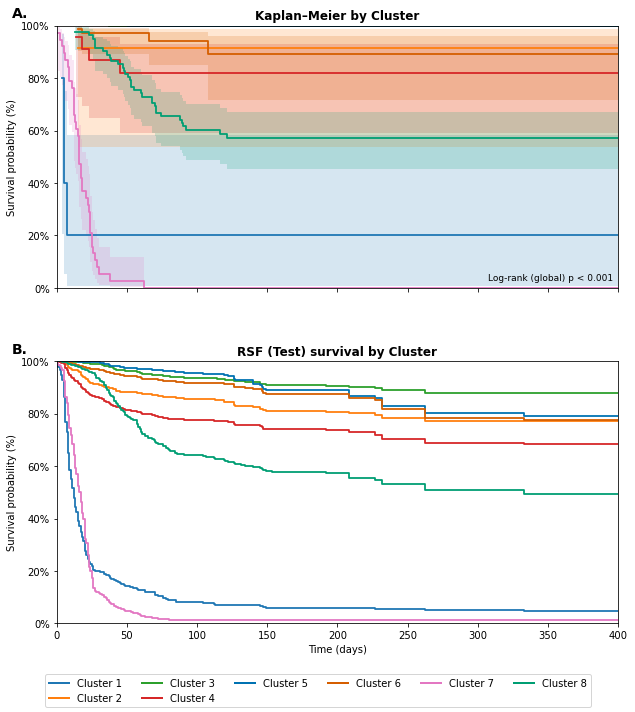

[Saved] /media/bami/JHA/24-07_nedis/KNN/Clustering/P1_NEC/Surv/figs/Figure3_KM_RSF_Test_CMYK.tif


In [58]:
fig3_path = plot_fig3_km_rsf_test_composite(
    final_rsf=final_rsf,
    y_test=y_test,
    X_test_scd=X_test_scd,
    ipt=ipt,
    out_dir=os.path.join(BASE_DIR, "figs"),
    dpi=600,
    to_cmyk=True,
    panel_A="A.", panel_B="B.",
    palette_base=cluster_palette,
    km_band_alpha=0.18,
    km_ci_alpha=0.05,
    x_max=400
)
print("[Saved]", fig3_path)

Training model...
Model saved.

========== [1. VALIDATION SET EVALUATION] ==========
[Validation] C-index = 0.9651 (95% CI: 0.9489 - 0.9797)
[Validation] Mean AUC = 0.9850 (95% CI: 0.9620 - 0.9943)
[Validation Classification Metrics (Optimal Cutoff: 18.6613)]
 - Sensitivity : 0.8696
 - Specificity : 0.9412
 - Accuracy    : 0.9171
 - Balanced Acc: 0.9054

========== [2. TEST SET EVALUATION] ==========
[Test] C-index = 0.9763 (95% CI: 0.9671 - 0.9845)
[Test] Mean AUC = 0.9945 (95% CI: 0.9882 - 0.9975)
[Test Classification Metrics (Optimal Cutoff: 37.6586)]
 - Sensitivity : 0.9302
 - Specificity : 0.9825
 - Accuracy    : 0.9650
 - Balanced Acc: 0.9563



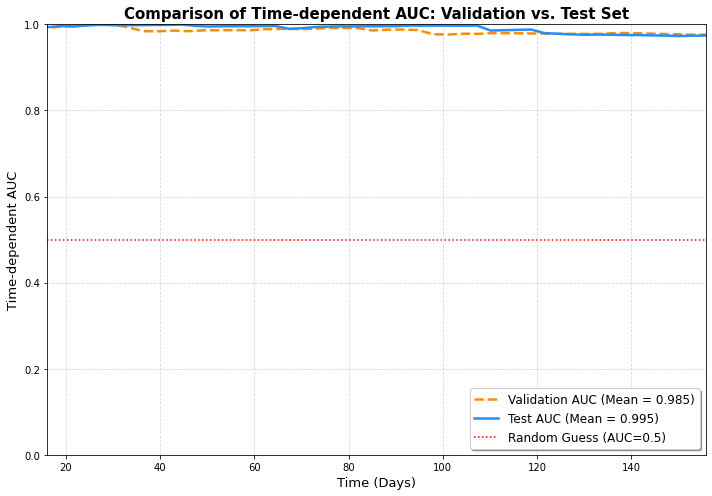

In [8]:
## re-Make RESULTS (C-index, AUC)

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc
from sklearn.metrics import roc_curve, confusion_matrix

# SEED = SEED  # 기존에 사용하셨던 SEED 값으로 변경 가능

# 1. 경로 설정
base_dir = "/media/bami/JHA/24-07_nedis/KNN/Clustering/P1_NEC/Surv"
scd_dir = os.path.join(base_dir, "datasets/scd")
lbl_dir = os.path.join(base_dir, "datasets/label")
model_out = os.path.join(base_dir, "models")
fig_out = os.path.join(base_dir, "figs")

os.makedirs(model_out, exist_ok=True)
os.makedirs(fig_out, exist_ok=True)

# 2. 데이터 로드
X_train_scd = pd.read_csv(os.path.join(scd_dir, "X_train_scd.csv"))
X_val_scd = pd.read_csv(os.path.join(scd_dir, "X_val_scd.csv"))
X_test_scd = pd.read_csv(os.path.join(scd_dir, "X_test_scd.csv"))

y_train_df = pd.read_csv(os.path.join(lbl_dir, "y_train.csv"))
y_val_df = pd.read_csv(os.path.join(lbl_dir, "y_val.csv"))
y_test_df = pd.read_csv(os.path.join(lbl_dir, "y_test.csv"))

# sksurv 형식에 맞게 label 변환 (Structured array)
def make_sksurv_label(df):
    return np.array([(bool(e), float(t)) for e, t in zip(df['event'], df['time'])],
                    dtype=[('event', '?'), ('time', '<f8')])

y_train = make_sksurv_label(y_train_df)
y_val = make_sksurv_label(y_val_df)
y_test = make_sksurv_label(y_test_df)

# 3. 모델 정의 및 학습 (최적 하이퍼파라미터 적용)
best_params = {
    'max_depth': 15, 
    'max_features': 20, 
    'min_samples_leaf': 5, 
    'min_samples_split': 5, 
    'n_estimators': 250
}

final_rsf = RandomSurvivalForest(
    **best_params,
    random_state=SEED,
    n_jobs=-1
)

print("Training model...")
final_rsf.fit(X_train_scd, y_train)

# 4. 모델 저장
with open(os.path.join(model_out, "rsf_M02.pkl"), "wb") as f:
    pickle.dump(final_rsf, f)
print("Model saved.\n")

# --- 95% CI 산출을 위한 Bootstrapping 함수 ---
def get_ci_bootstrap(y_true, risk_pred, metric='c_index', times=None, y_train_for_auc=None, n_bootstraps=1000):
    rng = np.random.RandomState(SEED)
    scores = []
    n_samples = len(risk_pred)
    
    for _ in range(n_bootstraps):
        indices = rng.randint(0, n_samples, n_samples)
        try:
            if metric == 'c_index':
                if len(np.unique(y_true['event'][indices])) < 2:
                    continue
                score = concordance_index_censored(y_true['event'][indices], y_true['time'][indices], risk_pred[indices])[0]
            elif metric == 'auc':
                _, score = cumulative_dynamic_auc(y_train_for_auc, y_true[indices], risk_pred[indices], times)
            scores.append(score)
        except Exception:
            continue
            
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    return lower, upper

# --- 분류 지표(Sens, Spec, Acc, Bal_Acc) 산출 함수 ---
def calc_classification_metrics(y_df, risk_scores, dataset_name=""):
    y_true_binary = y_df['event'].astype(int)
    
    # ROC 커브를 이용하여 최적의 절점(Youden's J index) 찾기
    fpr, tpr, thresholds = roc_curve(y_true_binary, risk_scores)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    # 최적 절점을 기준으로 이진 분류 예측
    y_pred_binary = (risk_scores >= optimal_threshold).astype(int)
    
    # 혼동 행렬(Confusion Matrix) 계산
    tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    balanced_accuracy = (sensitivity + specificity) / 2
    
    print(f"[{dataset_name} Classification Metrics (Optimal Cutoff: {optimal_threshold:.4f})]")
    print(f" - Sensitivity : {sensitivity:.4f}")
    print(f" - Specificity : {specificity:.4f}")
    print(f" - Accuracy    : {accuracy:.4f}")
    print(f" - Balanced Acc: {balanced_accuracy:.4f}\n")


# =========================================================
# 5. Validation Set 평가 (C-index, AUC, 분류 지표)
# =========================================================
print("========== [1. VALIDATION SET EVALUATION] ==========")
risk_val = final_rsf.predict(X_val_scd)

# 1) C-index
c_val = concordance_index_censored(y_val["event"], y_val["time"], risk_val)[0]
ci_val_lower, ci_val_upper = get_ci_bootstrap(y_val, risk_val, metric='c_index')
print(f"[Validation] C-index = {c_val:.4f} (95% CI: {ci_val_lower:.4f} - {ci_val_upper:.4f})")

# 2) Time-dependent AUC
times_val = np.linspace(np.percentile(y_val_df["time"], 10), np.percentile(y_val_df["time"], 90), 50)
auc_val, mean_auc_val = cumulative_dynamic_auc(y_train, y_val, risk_val, times_val)
auc_val_lower, auc_val_upper = get_ci_bootstrap(y_val, risk_val, metric='auc', times=times_val, y_train_for_auc=y_train)
print(f"[Validation] Mean AUC = {mean_auc_val:.4f} (95% CI: {auc_val_lower:.4f} - {auc_val_upper:.4f})")

# 3) 분류 지표
calc_classification_metrics(y_val_df, risk_val, "Validation")


# =========================================================
# 6. Test Set 평가 (C-index, AUC, 분류 지표)
# =========================================================
print("========== [2. TEST SET EVALUATION] ==========")
risk_test = final_rsf.predict(X_test_scd)

# 1) C-index
c_test = concordance_index_censored(y_test["event"], y_test["time"], risk_test)[0]
ci_test_lower, ci_test_upper = get_ci_bootstrap(y_test, risk_test, metric='c_index')
print(f"[Test] C-index = {c_test:.4f} (95% CI: {ci_test_lower:.4f} - {ci_test_upper:.4f})")

# 2) Time-dependent AUC
times_test = np.linspace(np.percentile(y_test_df["time"], 10), np.percentile(y_test_df["time"], 90), 50)
auc_test, mean_auc_test = cumulative_dynamic_auc(y_train, y_test, risk_test, times_test)
auc_test_lower, auc_test_upper = get_ci_bootstrap(y_test, risk_test, metric='auc', times=times_test, y_train_for_auc=y_train)
print(f"[Test] Mean AUC = {mean_auc_test:.4f} (95% CI: {auc_test_lower:.4f} - {auc_test_upper:.4f})")

# 3) 분류 지표
calc_classification_metrics(y_test_df, risk_test, "Test")

# 4) Validation 및 Test Set AUC 통합 시각화 (논문용 고해상도)
plt.figure(figsize=(10, 7))  # 시각적 가독성을 위해 크기를 가로 10, 세로 7로 확대

# Validation AUC 곡선 (점선 또는 다른 색상으로 구분)
plt.plot(times_val, auc_val, lw=2.5, color='darkorange', linestyle='--', 
         label=f'Validation AUC (Mean = {mean_auc_val:.3f})')
# Test AUC 곡선 (실선으로 강조)
plt.plot(times_test, auc_test, lw=2.5, color='dodgerblue', linestyle='-', 
         label=f'Test AUC (Mean = {mean_auc_test:.3f})')
# 기저선 (AUC 0.5)
plt.axhline(y=0.5, color='red', linestyle=':', lw=1.5, label='Random Guess (AUC=0.5)')

# 축 범위 및 레이블 설정
plt.ylim(0.0, 1.0)  # y축 0부터 1까지 고정
plt.xlim(min(times_test), max(times_test)) # x축 범위 최적화
plt.xlabel("Time (Days)", fontsize=13)
plt.ylabel("Time-dependent AUC", fontsize=13)
plt.title("Comparison of Time-dependent AUC: Validation vs. Test Set", fontsize=15, fontweight='bold')

# 디자인 요소 추가
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)
plt.tight_layout()

# 고해상도 저장 (300 DPI)
plt.savefig(os.path.join(fig_out, "AUC_comparison_val_test.png"), dpi=300)
plt.show()

In [22]:
# Test feature 불러오기
X_test_scd = pd.read_csv(os.path.join(scd_dir, "X_test_scd.csv"))
X_test_scd.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
X_test_scd.set_index('idx_code', inplace=True)

# Test set에 해당하는 cluster labels 추출
test_cluster_labels = df.loc[X_test_scd.index, 'Cluster_Labels']

# Count + proportion 계산
test_cluster_summary = (
    test_cluster_labels
    .value_counts()
    .sort_index()
    .rename_axis('Cluster_Labels')
    .reset_index(name='Count')
)

test_cluster_summary['Proportion'] = test_cluster_summary['Count'] / len(test_cluster_labels)
test_cluster_summary['Percentage (%)'] = (test_cluster_summary['Proportion'] * 100).round(2)

print(test_cluster_summary)

   Cluster_Labels  Count  Proportion  Percentage (%)
0               1      5    0.019455            1.95
1               2     12    0.046693            4.67
2               3      6    0.023346            2.33
3               4     23    0.089494            8.95
4               5     19    0.073930            7.39
5               6     72    0.280156           28.02
6               7     38    0.147860           14.79
7               8     82    0.319066           31.91


In [23]:
# 전체 데이터에서 Cluster_Labels count / proportion 확인
total_cluster_summary = (
    df['Cluster_Labels']
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis('Cluster_Labels')
    .reset_index(name='Count')
)

total_cluster_summary['Proportion'] = total_cluster_summary['Count'] / len(df)
total_cluster_summary['Percentage (%)'] = (total_cluster_summary['Proportion'] * 100).round(2)

print(total_cluster_summary)

   Cluster_Labels  Count  Proportion  Percentage (%)
0               1    353    0.017345            1.73
1               2   3701    0.181849           18.18
2               3   1812    0.089033            8.90
3               4   3992    0.196148           19.61
4               5   1454    0.071443            7.14
5               6   4726    0.232213           23.22
6               7   1536    0.075472            7.55
7               8   2778    0.136498           13.65


In [27]:
## RSF_test 인원에서 RMST


from lifelines import KaplanMeierFitter

base_dir = "/media/bami/JHA/24-07_nedis/KNN/Clustering/P1_NEC/Surv"
scd_dir = os.path.join(base_dir, "datasets/scd")
lbl_dir = os.path.join(base_dir, "datasets/label")
model_out = os.path.join(base_dir, "models")
out_dir = os.path.join(base_dir, "RMST")

os.makedirs(out_dir, exist_ok=True)

DATASET = "test"   # "train", "val", "test" 중 선택
model_path = os.path.join(model_out, "rsf_M02.pkl")


# =========================================================
# 1. Index 정리 함수
# =========================================================
def set_idx_code_index(df):
    df = df.copy()
    
    if 'idx_code' in df.columns:
        df = df.set_index('idx_code')
    elif 'Unnamed: 0' in df.columns:
        df = df.rename(columns={'Unnamed: 0': 'idx_code'})
        df = df.set_index('idx_code')
    
    return df


# =========================================================
# 2. 전체 원본 데이터 로드: Cluster_Labels 확인용
# =========================================================
df = pd.read_csv(f'{ipt}/KNN_df_combined_1.csv')
df = set_idx_code_index(df)

print(f"[Original df] n = {len(df)}")
print(f"[Original df] Cluster_Labels exists: {'Cluster_Labels' in df.columns}")


# =========================================================
# 3. 저장된 RSF dataset 로드
# =========================================================
X_train_scd = set_idx_code_index(pd.read_csv(os.path.join(scd_dir, "X_train_scd.csv")))
X_val_scd   = set_idx_code_index(pd.read_csv(os.path.join(scd_dir, "X_val_scd.csv")))
X_test_scd  = set_idx_code_index(pd.read_csv(os.path.join(scd_dir, "X_test_scd.csv")))

y_train_df = set_idx_code_index(pd.read_csv(os.path.join(lbl_dir, "y_train.csv")))
y_val_df   = set_idx_code_index(pd.read_csv(os.path.join(lbl_dir, "y_val.csv")))
y_test_df  = set_idx_code_index(pd.read_csv(os.path.join(lbl_dir, "y_test.csv")))

dataset_map = {
    "train": (X_train_scd, y_train_df),
    "val":   (X_val_scd, y_val_df),
    "test":  (X_test_scd, y_test_df),
}

X_rsf, y_rsf_df = dataset_map[DATASET]

print(f"[{DATASET}] X shape:", X_rsf.shape)
print(f"[{DATASET}] y shape:", y_rsf_df.shape)


# =========================================================
# 4. y_df index가 없거나 맞지 않는 경우 보정
# =========================================================
if not y_rsf_df.index.equals(X_rsf.index):
    print("[WARN] y index does not match X index.")
    print("       Assuming y file order matches X file order.")
    y_rsf_df = y_rsf_df.copy()
    y_rsf_df.index = X_rsf.index

print("[Check] X-y index matched:", X_rsf.index.equals(y_rsf_df.index))


# =========================================================
# 5. RSF 인원 기준 Cluster_Labels 추출
# =========================================================
missing_idx = X_rsf.index.difference(df.index)
print(f"[Check] Missing idx in original df: {len(missing_idx)}")

if len(missing_idx) > 0:
    raise ValueError("Some RSF indices are not found in the original df.")

clusters_rsf = df.loc[X_rsf.index, 'Cluster_Labels']

print("[RSF cluster distribution]")
print(clusters_rsf.value_counts().sort_index())


# =========================================================
# 6. 저장된 RSF model 로드
# =========================================================
with open(model_path, "rb") as f:
    final_rsf = pickle.load(f)

print(f"Loaded model: {model_path}")


# =========================================================
# 7. RSF survival prediction matrix 생성
# =========================================================
# 모델이 학습 당시 사용한 feature 이름 확인
model_features = list(final_rsf.feature_names_in_)

print(f"[Model features] n = {len(model_features)}")
print(model_features[:5], "...")

# 예측용 X 생성
X_pred = X_rsf.copy()

# 학습 당시 idx_code가 feature로 들어갔다면 다시 column으로 추가
if 'idx_code' in model_features and 'idx_code' not in X_pred.columns:
    X_pred = X_pred.copy()
    X_pred['idx_code'] = X_pred.index

# 모델 feature 순서에 맞춤
missing_features = [c for c in model_features if c not in X_pred.columns]
extra_features = [c for c in X_pred.columns if c not in model_features]

print("[Check] Missing model features:", missing_features)
print("[Check] Extra current features:", len(extra_features))

if len(missing_features) > 0:
    raise ValueError(f"Missing features for prediction: {missing_features}")

X_pred = X_pred[model_features]

# 숫자형 변환
X_pred = X_pred.apply(pd.to_numeric, errors='coerce')

# 혹시 남은 NaN 확인
print("[Check] NaN count in X_pred:", X_pred.isna().sum().sum())

# RSF survival prediction
surv_funcs = final_rsf.predict_survival_function(X_pred)

# 공통 time grid
t = final_rsf.unique_times_

# N x T survival matrix
S_pred_mat = np.vstack([fn(t) for fn in surv_funcs])

print("t shape:", t.shape)
print("S_pred_mat shape:", S_pred_mat.shape)


# =========================================================
# 8. KM curve helper
# =========================================================
def _km_curve_and_ci(dur, evt, t, alpha=0.05):
    kmf = KaplanMeierFitter(alpha=alpha)
    kmf.fit(durations=dur, event_observed=evt)
    
    S_km = kmf.survival_function_at_times(t).values
    
    return S_km, None, None


# =========================================================
# 9. RMST table function
# =========================================================
def compute_rmst_table(
    t, y_time, y_event, S_pred_mat, clusters,
    alpha_km=0.05,
    clusters_to_use=None
):
    clusters = np.asarray(clusters)
    y_time   = np.asarray(y_time)
    y_event  = np.asarray(y_event).astype(int)

    if clusters_to_use is None:
        clusters_to_use = np.unique(clusters[~pd.isna(clusters)])
    else:
        clusters_to_use = list(clusters_to_use)

    rows = []

    for c in clusters_to_use:
        mask = (clusters == c)
        n_c = int(mask.sum())

        if n_c == 0:
            print(f"[warn] cluster {c}: no sample")
            continue

        dur_c = y_time[mask]
        evt_c = y_event[mask]
        S_c   = S_pred_mat[mask]

        S_km, _, _ = _km_curve_and_ci(
            dur=dur_c,
            evt=evt_c,
            t=t,
            alpha=alpha_km
        )

        _, S_rsf, _ = np.percentile(S_c, [5, 50, 95], axis=0)

        rmst_km  = np.trapz(S_km, t)
        rmst_rsf = np.trapz(S_rsf, t)

        diff_days = rmst_rsf - rmst_km
        diff_pct  = (diff_days / rmst_km * 100.0) if rmst_km > 0 else np.nan

        nISE = int(evt_c.sum())
        nABC = int((evt_c == 0).sum())

        rows.append({
            "Dataset": DATASET,
            "Cluster": c,
            "Participants (n)": n_c,
            "nABC": nABC,
            "nISE": nISE,
            "RMST_KaplanMeier": rmst_km,
            "RMST_RSFpred": rmst_rsf,
            "ΔRMST (Days)": diff_days,
            "ΔRMST (%)": diff_pct,
        })

    return pd.DataFrame(rows)


# =========================================================
# 10. RMST 계산
# =========================================================
rmst_table_rsf = compute_rmst_table(
    t=t,
    y_time=y_rsf_df['time'].values,
    y_event=y_rsf_df['event'].values,
    S_pred_mat=S_pred_mat,
    clusters=clusters_rsf.values,
    alpha_km=0.05,
    clusters_to_use=None
)

rmst_table_rsf

Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.


[Original df] n = 20352
[Original df] Cluster_Labels exists: True
[test] X shape: (257, 110)
[test] y shape: (257, 2)
[WARN] y index does not match X index.
       Assuming y file order matches X file order.
[Check] X-y index matched: True
[Check] Missing idx in original df: 0
[RSF cluster distribution]
1     5
2    12
3     6
4    23
5    19
6    72
7    38
8    82
Name: Cluster_Labels, dtype: int64
Loaded model: /media/bami/JHA/24-07_nedis/KNN/Clustering/P1_NEC/Surv/models/rsf_M02.pkl
[Model features] n = 111
['idx_code', 'iarvppd', 'bdp_Moderate+', 'arre36_0', 'arre28_6'] ...
[Check] Missing model features: []
[Check] Extra current features: 0
[Check] NaN count in X_pred: 0
t shape: (219,)
S_pred_mat shape: (257, 219)


,Dataset,Cluster,Participants (n),nABC,nISE,RMST_KaplanMeier,RMST_RSFpred,ΔRMST (Days),ΔRMST (%)
0,test,1,5,1,4,76.800000,13.558155,-63.241845,-82.346152
1,test,2,12,11,1,335.791667,322.401186,-13.390481,-3.987735
2,test,3,6,6,0,365.000000,336.082030,-28.917970,-7.922732
3,test,4,23,19,4,304.234300,307.175337,2.941037,0.966701
4,test,5,19,19,0,365.000000,330.693680,-34.306320,-9.398992
5,test,6,72,67,5,333.161503,329.880153,-3.281350,-0.984913
6,test,7,38,0,38,17.368421,16.486422,-0.881999,-5.078174
7,test,8,82,48,34,232.845558,305.679666,72.834108,31.280007


In [31]:
## C-index, AUC by Clusters

# =========================================================
# 0. Path
# =========================================================
base_dir = "/media/bami/JHA/24-07_nedis/KNN/Clustering/P1_NEC/Surv"
scd_dir = os.path.join(base_dir, "datasets/scd")
lbl_dir = os.path.join(base_dir, "datasets/label")
model_out = os.path.join(base_dir, "models")
out_dir = os.path.join(base_dir, "cluster_metrics")

os.makedirs(out_dir, exist_ok=True)

model_path = os.path.join(model_out, "rsf_M02.pkl")


# =========================================================
# 1. Helper
# =========================================================
def set_idx_code_index(df):
    df = df.copy()
    if 'idx_code' in df.columns:
        df = df.set_index('idx_code')
    elif 'Unnamed: 0' in df.columns:
        df = df.rename(columns={'Unnamed: 0': 'idx_code'})
        df = df.set_index('idx_code')
    return df


def make_sksurv_label(df):
    return np.array(
        [(bool(e), float(t)) for e, t in zip(df['event'], df['time'])],
        dtype=[('event', '?'), ('time', '<f8')]
    )


def align_X_to_model_features(X, model):
    X_pred = X.copy()
    model_features = list(model.feature_names_in_)

    # 기존 모델이 idx_code를 feature로 학습한 경우 복원
    if 'idx_code' in model_features and 'idx_code' not in X_pred.columns:
        X_pred['idx_code'] = X_pred.index

    missing_features = [c for c in model_features if c not in X_pred.columns]
    if missing_features:
        raise ValueError(f"Missing features for prediction: {missing_features}")

    X_pred = X_pred[model_features]
    X_pred = X_pred.apply(pd.to_numeric, errors='coerce')

    return X_pred


def compute_cluster_cindex_auc(
    dataset_name,
    X_scd,
    y_df,
    df_original,
    model,
    y_train,
    min_n=5,
    n_times=50
):
    # y index 보정
    if not y_df.index.equals(X_scd.index):
        y_df = y_df.copy()
        y_df.index = X_scd.index

    # Cluster label
    clusters = df_original.loc[X_scd.index, 'Cluster_Labels']

    # Prediction
    X_pred = align_X_to_model_features(X_scd, model)
    risk_scores = model.predict(X_pred)

    y_eval = make_sksurv_label(y_df)

    rows = []

    for cl in sorted(clusters.dropna().unique()):
        mask = (clusters == cl).values
        n_c = int(mask.sum())

        y_c = y_eval[mask]
        risk_c = risk_scores[mask]
        y_df_c = y_df.iloc[mask].copy()

        n_event = int(y_df_c['event'].sum())
        n_nonevent = int((y_df_c['event'] == 0).sum())

        row = {
            "Dataset": dataset_name,
            "Cluster": cl,
            "Participants (n)": n_c,
            "nABC": n_nonevent,
            "nISE": n_event,
            "C-index": np.nan,
            "Mean AUC": np.nan,
            "Status": "OK"
        }

        # -----------------------------
        # C-index
        # -----------------------------
        try:
            if n_c < min_n:
                row["Status"] = f"Skipped: n < {min_n}"
            elif len(np.unique(y_c['event'])) < 2:
                row["Status"] = "Skipped: only one event class"
            else:
                row["C-index"] = concordance_index_censored(
                    y_c["event"],
                    y_c["time"],
                    risk_c
                )[0]
        except Exception as e:
            row["Status"] = f"C-index error: {e}"

        # -----------------------------
        # Time-dependent AUC
        # -----------------------------
        try:
            if n_c >= min_n and len(np.unique(y_c['event'])) >= 2:
                t_min = np.percentile(y_df_c["time"], 10)
                t_max = np.percentile(y_df_c["time"], 90)

                # cumulative_dynamic_auc는 evaluation time이 test follow-up range 안에 있어야 함
                times_c = np.linspace(t_min, t_max, n_times)

                auc_c, mean_auc_c = cumulative_dynamic_auc(
                    y_train,
                    y_c,
                    risk_c,
                    times_c
                )

                row["Mean AUC"] = mean_auc_c

        except Exception as e:
            if row["Status"] == "OK":
                row["Status"] = f"AUC error: {e}"
            else:
                row["Status"] += f" / AUC error: {e}"

        rows.append(row)

    return pd.DataFrame(rows)


# =========================================================
# 2. Load original df with Cluster_Labels
# =========================================================
df = pd.read_csv(f'{ipt}/KNN_df_combined_1.csv')
df = set_idx_code_index(df)

print(f"[Original df] n = {len(df)}")
print(f"[Original df] Cluster_Labels exists: {'Cluster_Labels' in df.columns}")


# =========================================================
# 3. Load saved datasets
# =========================================================
X_train_scd = set_idx_code_index(pd.read_csv(os.path.join(scd_dir, "X_train_scd.csv")))
X_val_scd   = set_idx_code_index(pd.read_csv(os.path.join(scd_dir, "X_val_scd.csv")))
X_test_scd  = set_idx_code_index(pd.read_csv(os.path.join(scd_dir, "X_test_scd.csv")))

y_train_df = set_idx_code_index(pd.read_csv(os.path.join(lbl_dir, "y_train.csv")))
y_val_df   = set_idx_code_index(pd.read_csv(os.path.join(lbl_dir, "y_val.csv")))
y_test_df  = set_idx_code_index(pd.read_csv(os.path.join(lbl_dir, "y_test.csv")))

if not y_train_df.index.equals(X_train_scd.index):
    y_train_df.index = X_train_scd.index

y_train = make_sksurv_label(y_train_df)


# =========================================================
# 4. Load RSF model
# =========================================================
with open(model_path, "rb") as f:
    final_rsf = pickle.load(f)

print(f"Loaded model: {model_path}")


# =========================================================
# 5. Cluster-wise C-index / AUC
# =========================================================
results = []

for dataset_name, X_scd, y_df in [
    ("Internal validation", X_val_scd, y_val_df),
    ("Test", X_test_scd, y_test_df),
]:
    print(f"\n========== {dataset_name.upper()} ==========")

    res = compute_cluster_cindex_auc(
        dataset_name=dataset_name,
        X_scd=X_scd,
        y_df=y_df,
        df_original=df,
        model=final_rsf,
        y_train=y_train,
        min_n=5,
        n_times=50
    )

    print(res)
    results.append(res)

cluster_metric_table = pd.concat(results, ignore_index=True)
cluster_metric_table['C-index'] = cluster_metric_table['C-index'].round(4)
cluster_metric_table['Mean AUC'] = cluster_metric_table['Mean AUC'].round(4)


cluster_metric_table

Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.


[Original df] n = 20352
[Original df] Cluster_Labels exists: True
Loaded model: /media/bami/JHA/24-07_nedis/KNN/Clustering/P1_NEC/Surv/models/rsf_M02.pkl

========== INTERNAL VALIDATION ==========
               Dataset  Cluster  Participants (n)  nABC  nISE   C-index  \
0  Internal validation        1                 5     1     4  1.000000   
1  Internal validation        2                 4     3     1       NaN   
2  Internal validation        3                 8     6     2  0.800000   
3  Internal validation        4                23    18     5  0.928571   
4  Internal validation        5                 8     7     1  0.000000   
5  Internal validation        6                56    51     5  0.971591   
6  Internal validation        7                28     1    27  0.877437   
7  Internal validation        8                73    49    24  0.948963   

   Mean AUC          Status  
0  1.000000              OK  
1       NaN  Skipped: n < 5  
2       NaN              OK  
3  0.98

,Dataset,Cluster,Participants (n),nABC,nISE,C-index,Mean AUC,Status
0,Internal validation,1,5,1,4,1.0000,1.0000,OK
1,Internal validation,2,4,3,1,NaN,NaN,Skipped: n < 5
2,Internal validation,3,8,6,2,0.8000,NaN,OK
3,Internal validation,4,23,18,5,0.9286,0.9830,OK
4,Internal validation,5,8,7,1,0.0000,NaN,OK
5,Internal validation,6,56,51,5,0.9716,1.0000,OK
6,Internal validation,7,28,1,27,0.8774,0.9377,OK
7,Internal validation,8,73,49,24,0.9490,0.9724,OK
8,Test,1,5,1,4,1.0000,1.0000,OK
9,Test,2,12,11,1,1.0000,1.0000,OK
